# 7.3 – Customer Churn Analysis and Retain Prediction

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import ConfusionMatrixDisplay, PrecisionRecallDisplay, RocCurveDisplay, classification_report

%config InlineBackend.figure_format = 'retina'

# 1. Dataset Overview

In [2]:
data = pd.read_csv('/Users/konansul/Desktop/course-ml/DATA/Telco-Customer-Churn.csv')

First, let’s look at the dataset. This dataset, provided by IBM, contains customer information aimed at predicting churn behavior in a telecommunications company. Each row represents an individual customer, with features covering demographics, account details, and the services they’ve subscribed to. The primary goal is to analyze these attributes to build models that help identify customers at risk of leaving. It contains 7032 rows and 21 columns. Some of the features are categorical, and others are numerical. However, since we have categorical columns, the feature matrix will change after we apply one-hot encoding. For now let the feature matrix be denoted as:

$$
X = \mathbb{R}^{7032 \times 21}
$$

The target column vector is `Churn`. Since the target variable $\mathbf{y}$ consists of only two possible values `Yes` and `No`, this is a binary classification task.So the target column vector can be denoted as:

$$
\mathbf{y} \in \{ \text{Yes}, \text{No} \}^{7032}
$$
The goal is to predict whether a customer will churn (leave) or stay.

In [3]:
data

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7028,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7029,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7030,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


# 2. Exploratory Data Analysis (EDA)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 


In [5]:
data.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


We observe that there are no missing (null) values in the dataset, which is a positive aspect as it simplifies data preprocessing.

In [6]:
data.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Using the `value_counts()` function and a count plot, we observe that the number of `No` values is much more higher than the number of `Yes` values. This indicates that the classes are imbalanced, which can negatively affect the performance of our model. Therefore, we will need to handle this imbalance for example, by using the `class_weight = 'balanced'` parameter in the models.

In [7]:
data['Churn'].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

<Axes: xlabel='Churn', ylabel='count'>

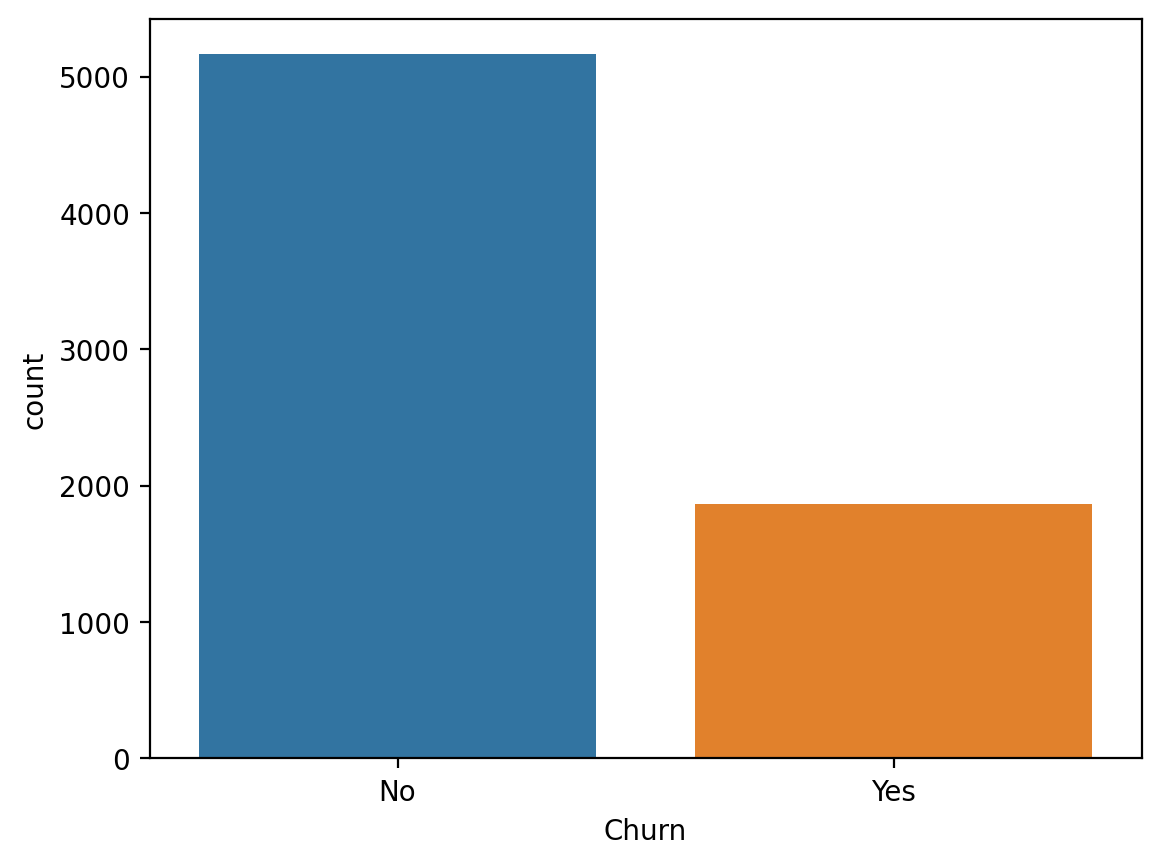

In [8]:
sns.countplot(x = 'Churn', hue = 'Churn', data = data)

The box plot below shows the relationship between the Churn column and TotalCharges. We observe that: Customers with higher `TotalCharges` are less likely to churn and customers with lower `TotalCharges` are more likely to churn. This suggests a trend: low-paying customers tend to leave more often. However, there are also some outliers for example, a few customers with total charges around 7000–8000 have still churned. This indicates that other factors may influence customer churn.

<Axes: xlabel='Churn', ylabel='TotalCharges'>

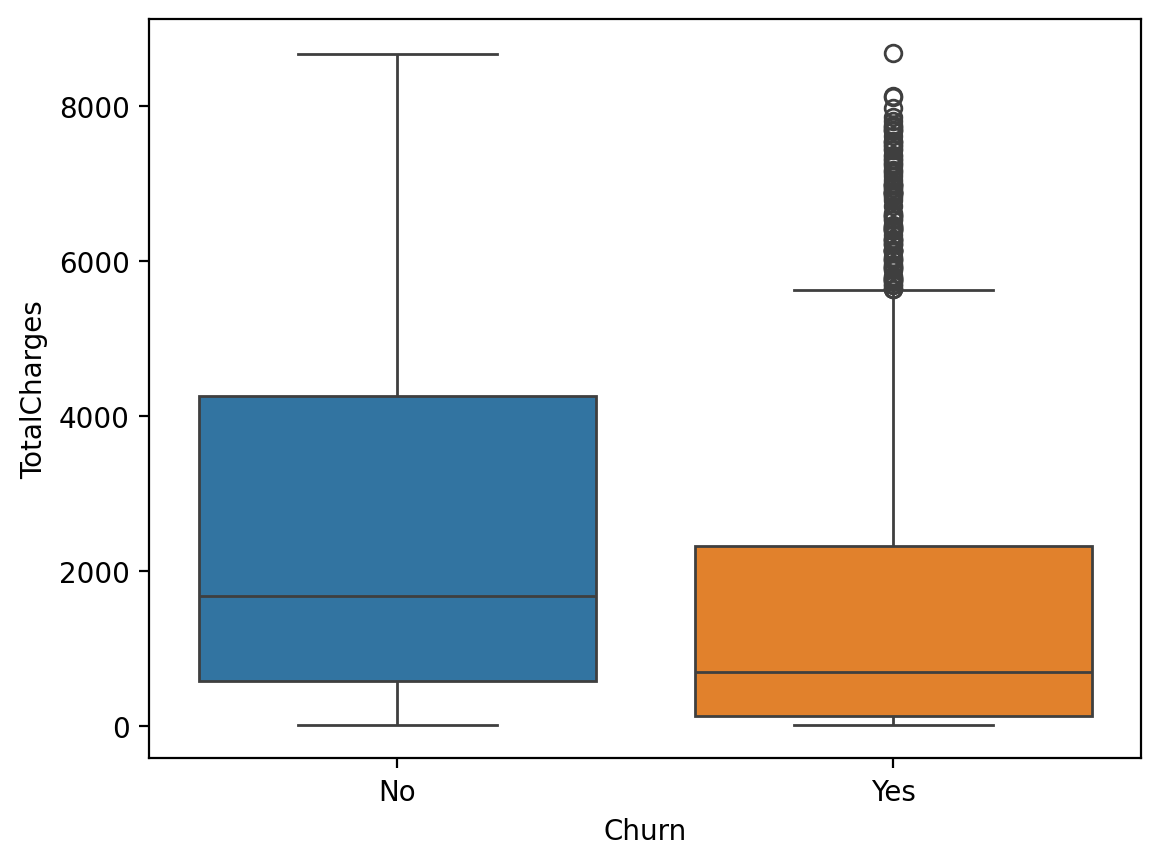

In [9]:
sns.boxplot(x = 'Churn', y = 'TotalCharges', hue = 'Churn', data = data)

From the plot below, we observe that customers with month-to-month contracts are much more likely to churn, however, customers with one-year or two-year contracts are less likely to churn, especially those with two-year contracts. The result is less clear for one-year contracts in that case, the box representing churned customers `Churn = Yes` is higher than the one for non-churned customers, which is counterintuitive. This may be due to sample size differences or outliers. In contrast, for two-year contracts, the trend is much clearer and more consistent: most customers did not churn, and their total charges are generally higher.

<Axes: xlabel='Contract', ylabel='TotalCharges'>

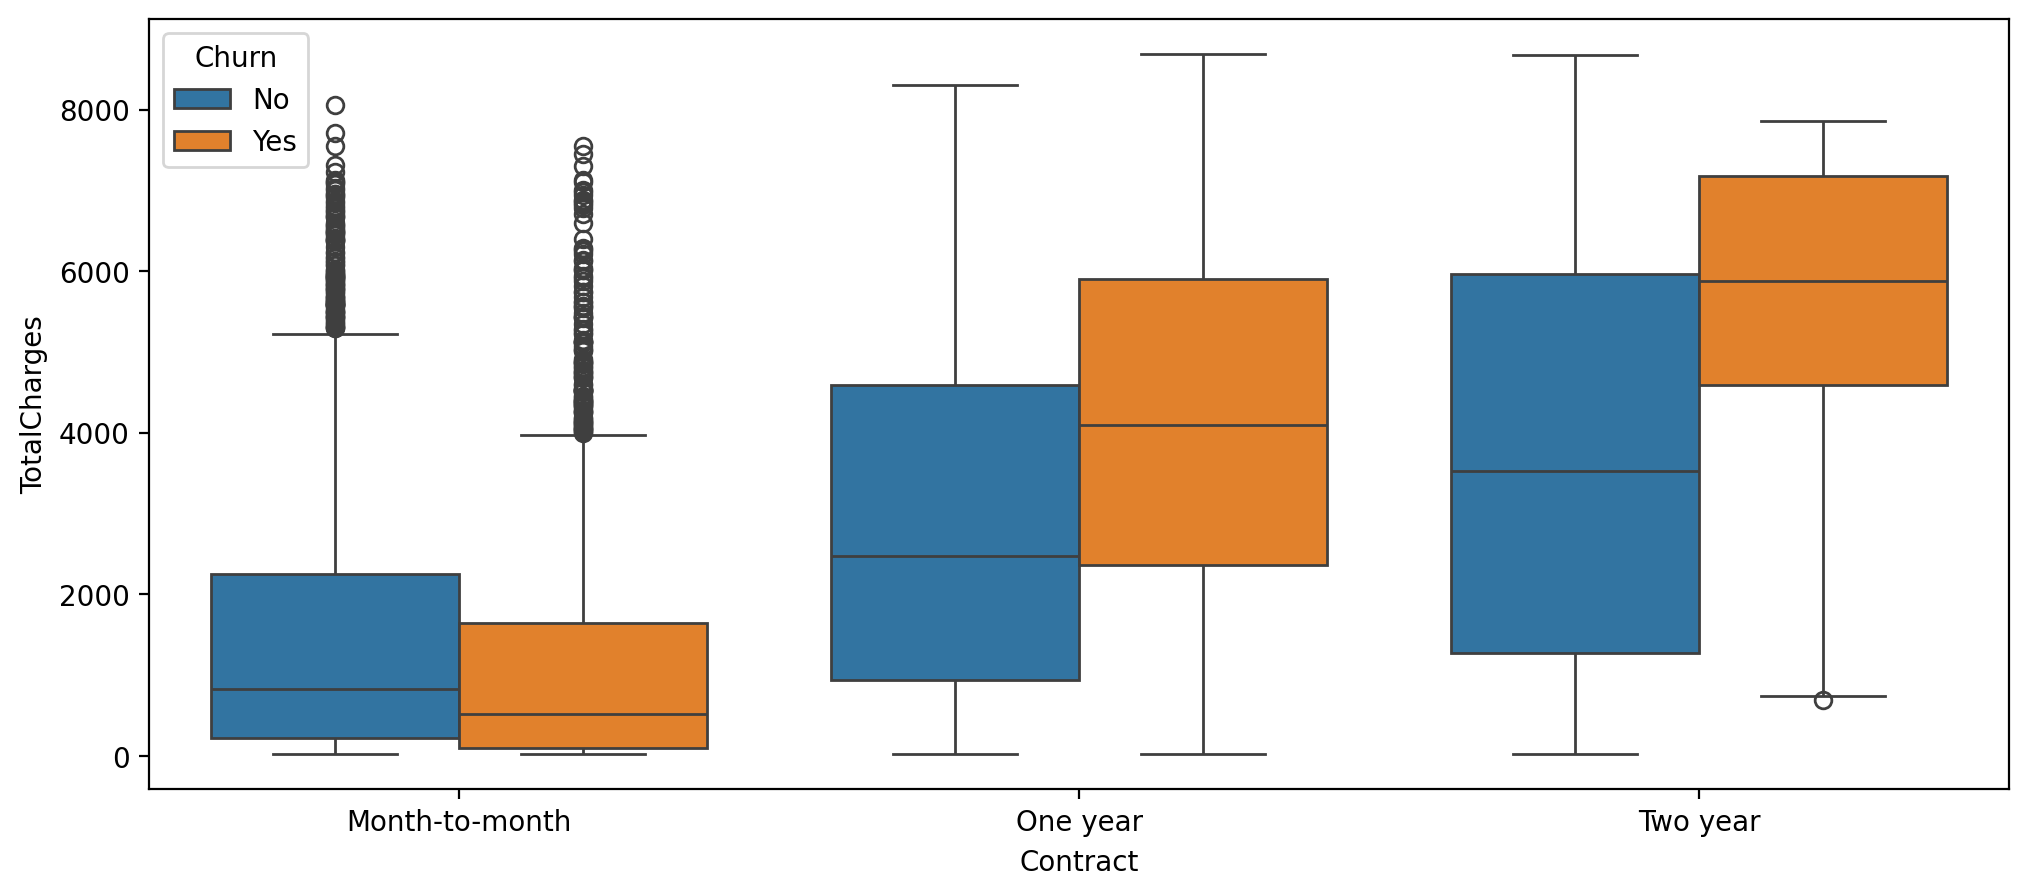

In [10]:
plt.figure(figsize = (12,5))
sns.boxplot(x = 'Contract', y = 'TotalCharges', hue = 'Churn', data = data)

## 2.1 Correlation Analysis

Now, let’s perform a correlation analysis to see how the Churn column relates to other features in the dataset. But first our dataset contains many categorical columns, so first we need to convert them into a numerical format before using them. The `customerID` column contains 7032 unique values, one for each row. Since it’s a unique identifier, it does not contain any useful information for prediction. If we were to apply one-hot encoding to this column, it would create 7032 new columns, one for each unique ID. This would unnecessarily increase the dimensionality of our dataset and add no value to the analysis. To avoid this, we have to drop the `customerID` column. After dropping customerID, we can use `pd.get_dummies` function to apply one-hot encoding to convert all categorical columns into numerical format.

In [11]:
data_dummy = pd.get_dummies(data.drop('customerID', axis = 1))

In [12]:
data_dummy

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,...,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_No,Churn_Yes
0,0,1,29.85,29.85,True,False,False,True,True,False,...,False,False,False,True,False,False,True,False,True,False
1,0,34,56.95,1889.50,False,True,True,False,True,False,...,True,False,True,False,False,False,False,True,True,False
2,0,2,53.85,108.15,False,True,True,False,True,False,...,False,False,False,True,False,False,False,True,False,True
3,0,45,42.30,1840.75,False,True,True,False,True,False,...,True,False,True,False,True,False,False,False,True,False
4,0,2,70.70,151.65,True,False,True,False,True,False,...,False,False,False,True,False,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,0,24,84.80,1990.50,False,True,False,True,False,True,...,True,False,False,True,False,False,False,True,True,False
7028,0,72,103.20,7362.90,True,False,False,True,False,True,...,True,False,False,True,False,True,False,False,True,False
7029,0,11,29.60,346.45,True,False,False,True,False,True,...,False,False,False,True,False,False,True,False,True,False
7030,1,4,74.40,306.60,False,True,False,True,True,False,...,False,False,False,True,False,False,False,True,False,True


No we can use the `.corr()` method to analyze how each feature correlates with the `Churn_Yes` column. By sorting the correlation values, we can identify which features are most strongly related to customer churn. 

In [13]:
datacorr = data_dummy.corr()['Churn_Yes'].sort_values()[1 : -1]

In [14]:
datacorr.index[:10]

Index(['tenure', 'Contract_Two year', 'InternetService_No',
       'StreamingTV_No internet service', 'TechSupport_No internet service',
       'DeviceProtection_No internet service',
       'OnlineBackup_No internet service',
       'OnlineSecurity_No internet service',
       'StreamingMovies_No internet service', 'TotalCharges'],
      dtype='object')

From the bar plot we can observe that the feature `Contract_Month-to-month` has a correlation of approximately 0.4 with churn. This suggests that customers with month-to-month contracts are more likely to churn compared to those with longer-term contracts. The `tenure` column, which represents the number of months a customer has been with the company, is negatively correlated with churn with approximate value -0.35. This means that customers who have stayed longer are less likely to leave, the longer the tenure, the lower the chance of churn.

In [15]:
datacorr = pd.DataFrame({'Feature': datacorr.index, 'Correlation': datacorr.values})

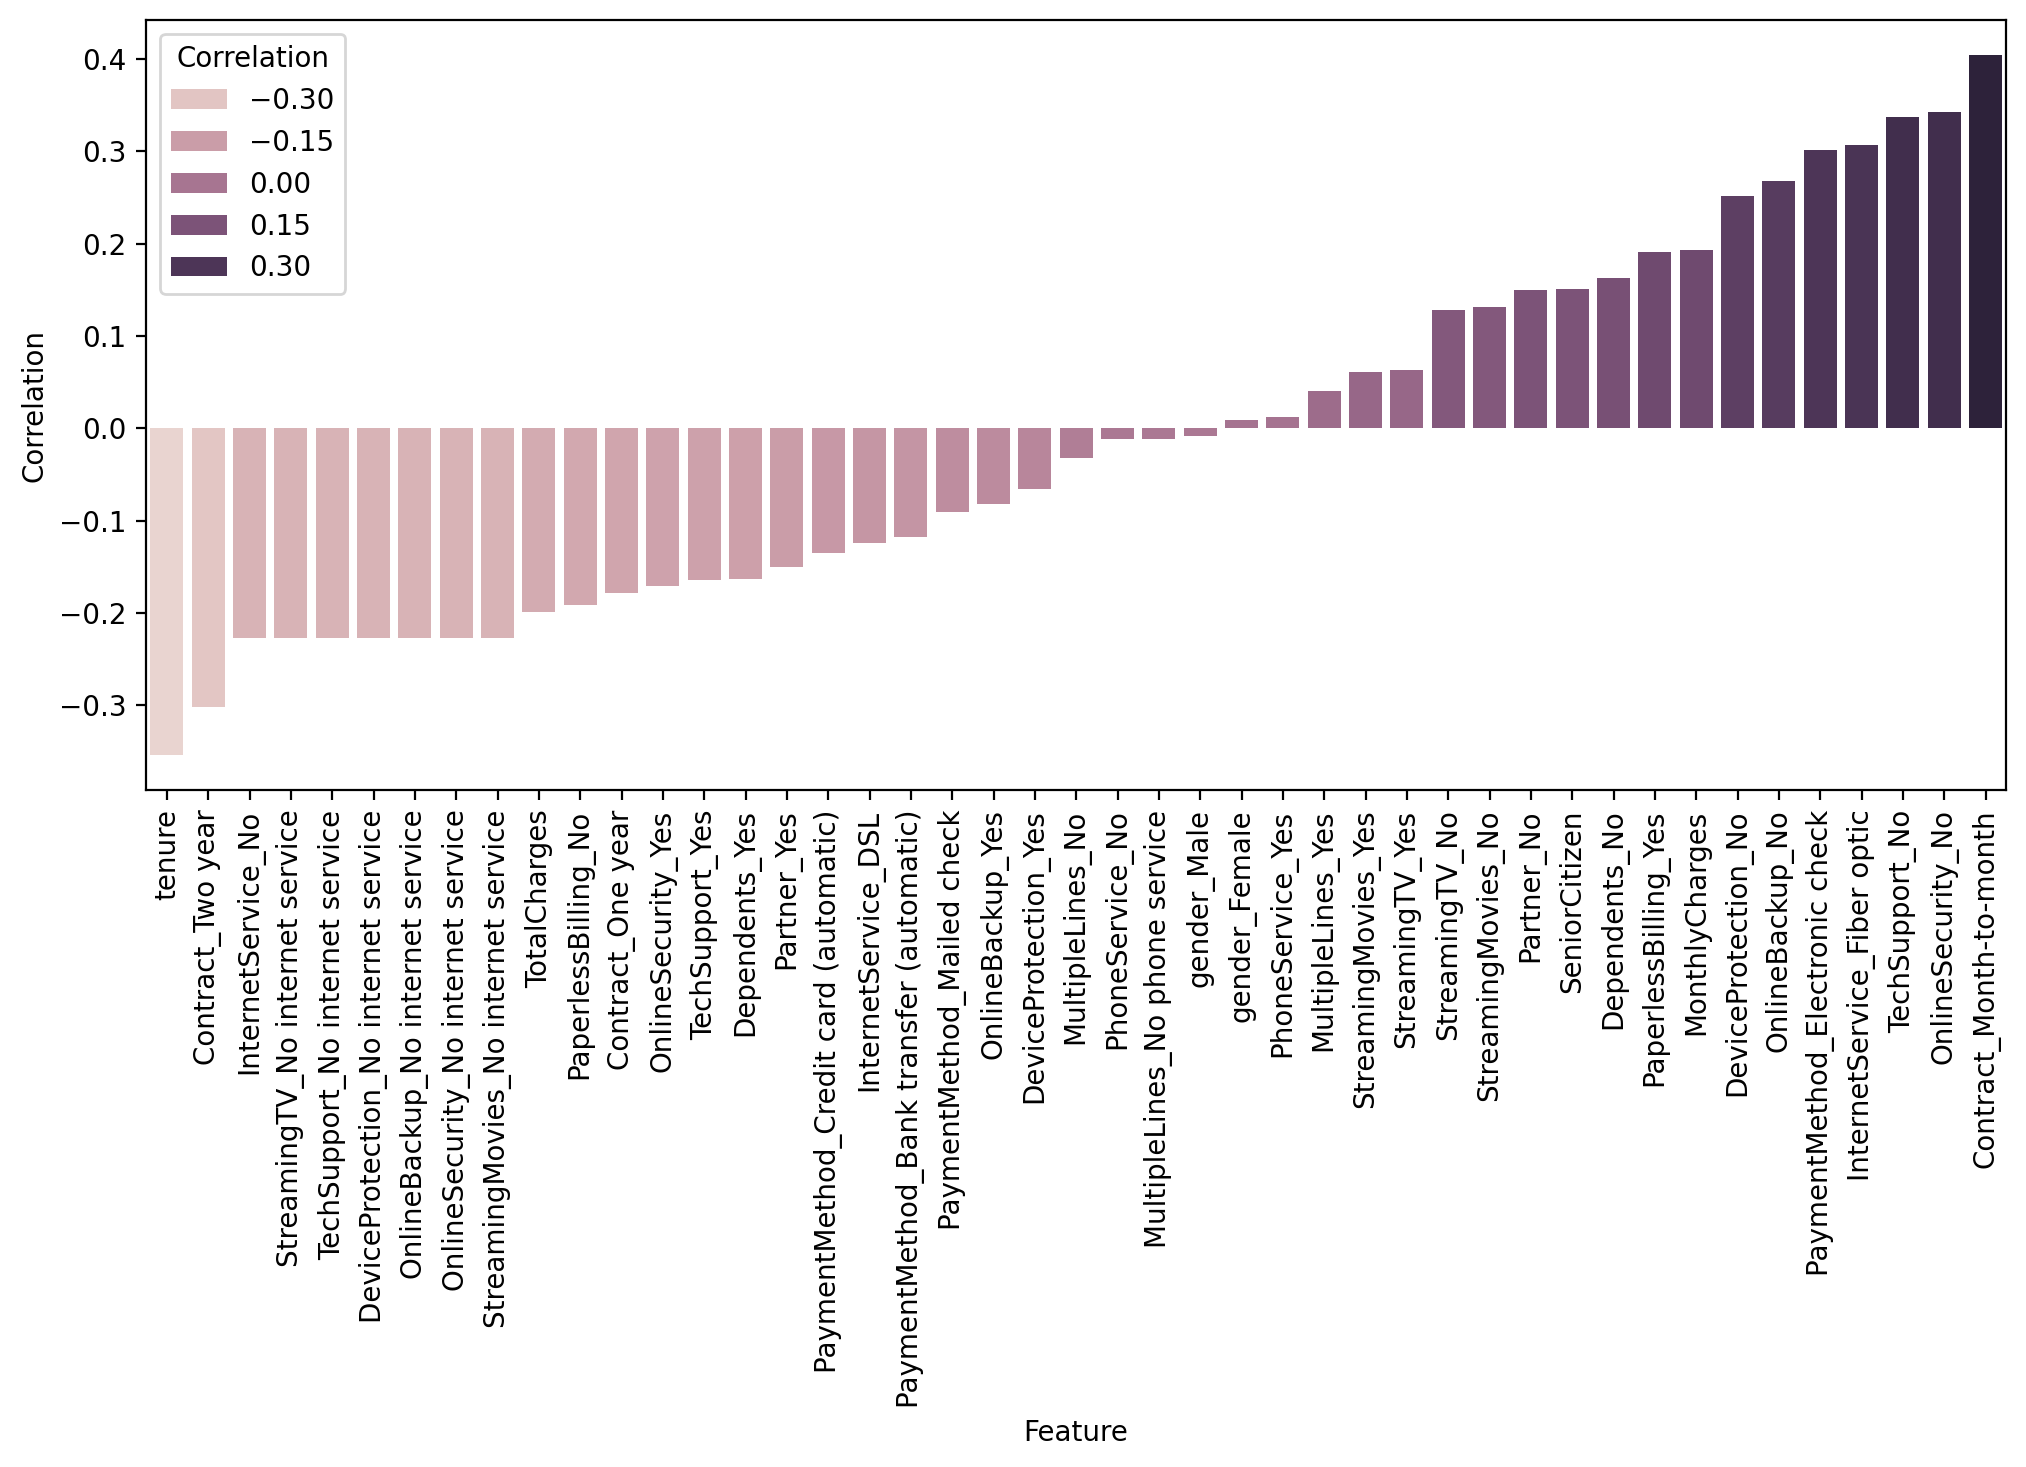

In [16]:
plt.figure(figsize = (12, 5))
sns.barplot(x = datacorr['Feature'], y = datacorr['Correlation'], hue = 'Correlation', data = datacorr)
plt.xticks(rotation = 90)
plt.show()

## 2.2 Churn Analysis

The histogram below shows how customers are distributed according to the `tenure` column. A very large number of customers (over 800) left the company within the first month (tenure = 0). This indicates a high churn rate among new users. Many customers stayed for the maximum possible duration 72 months (6 years). This suggests the presence of a loyal customer base. Between 1 and 70 months, the distribution is relatively uniform, with small fluctuations.

<Axes: xlabel='tenure', ylabel='Count'>

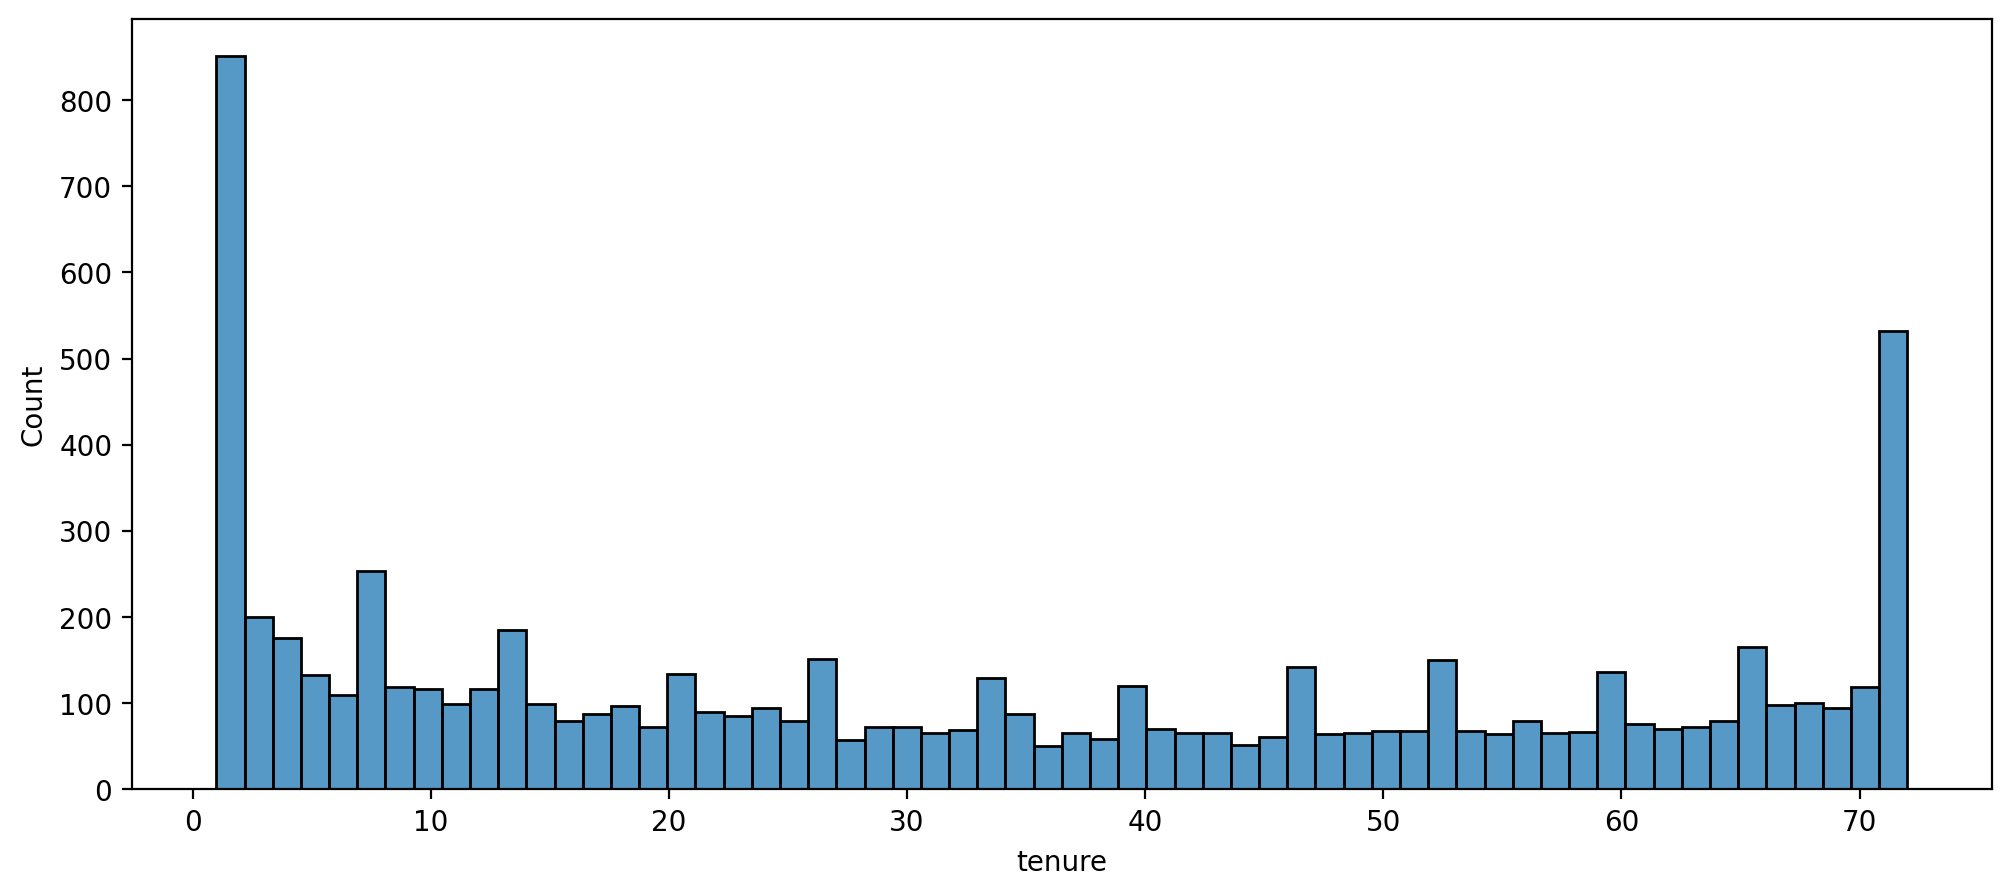

In [17]:
plt.figure(figsize = (12, 5))
sns.histplot(data['tenure'], bins = 60)

In [18]:
data['Contract'].value_counts()

Contract
Month-to-month    3875
Two year          1685
One year          1472
Name: count, dtype: int64

Since our earlier analysis showed that churn is strongly related to both the `Contract` and `tenure` columns, it’s helpful to visualize how these features interact. We can create a conditional plot showing the distribution of tenure for each combination of:
- Churn = Yes / No
- Contract = Month-to-month / One year / Two year

This results in six subplots, one for each combination. For churned customers (Churn = Yes), most are on month-to-month contracts. These customers tend to have low tenure, meaning they leave early. Very few customers with one-year or two-year contracts have churned. The number of churned customers decreases as contract length increases.

For non-churned customers (Churn = No), in one-year contracts, the distribution of tenure is relatively flat and stable. In two-year contracts, we observe that most customers have high tenure values and have not churned. This suggests that long-term contracts are associated with customer retention. At the end of the histogram around tenure = 72, we see a sharp spike in the number of customers.
This is expected, because 72 months (6 years) is the maximum recorded tenure in the dataset. This confirms the idea that longer contract durations and higher tenure are strong indicators of customer retention.

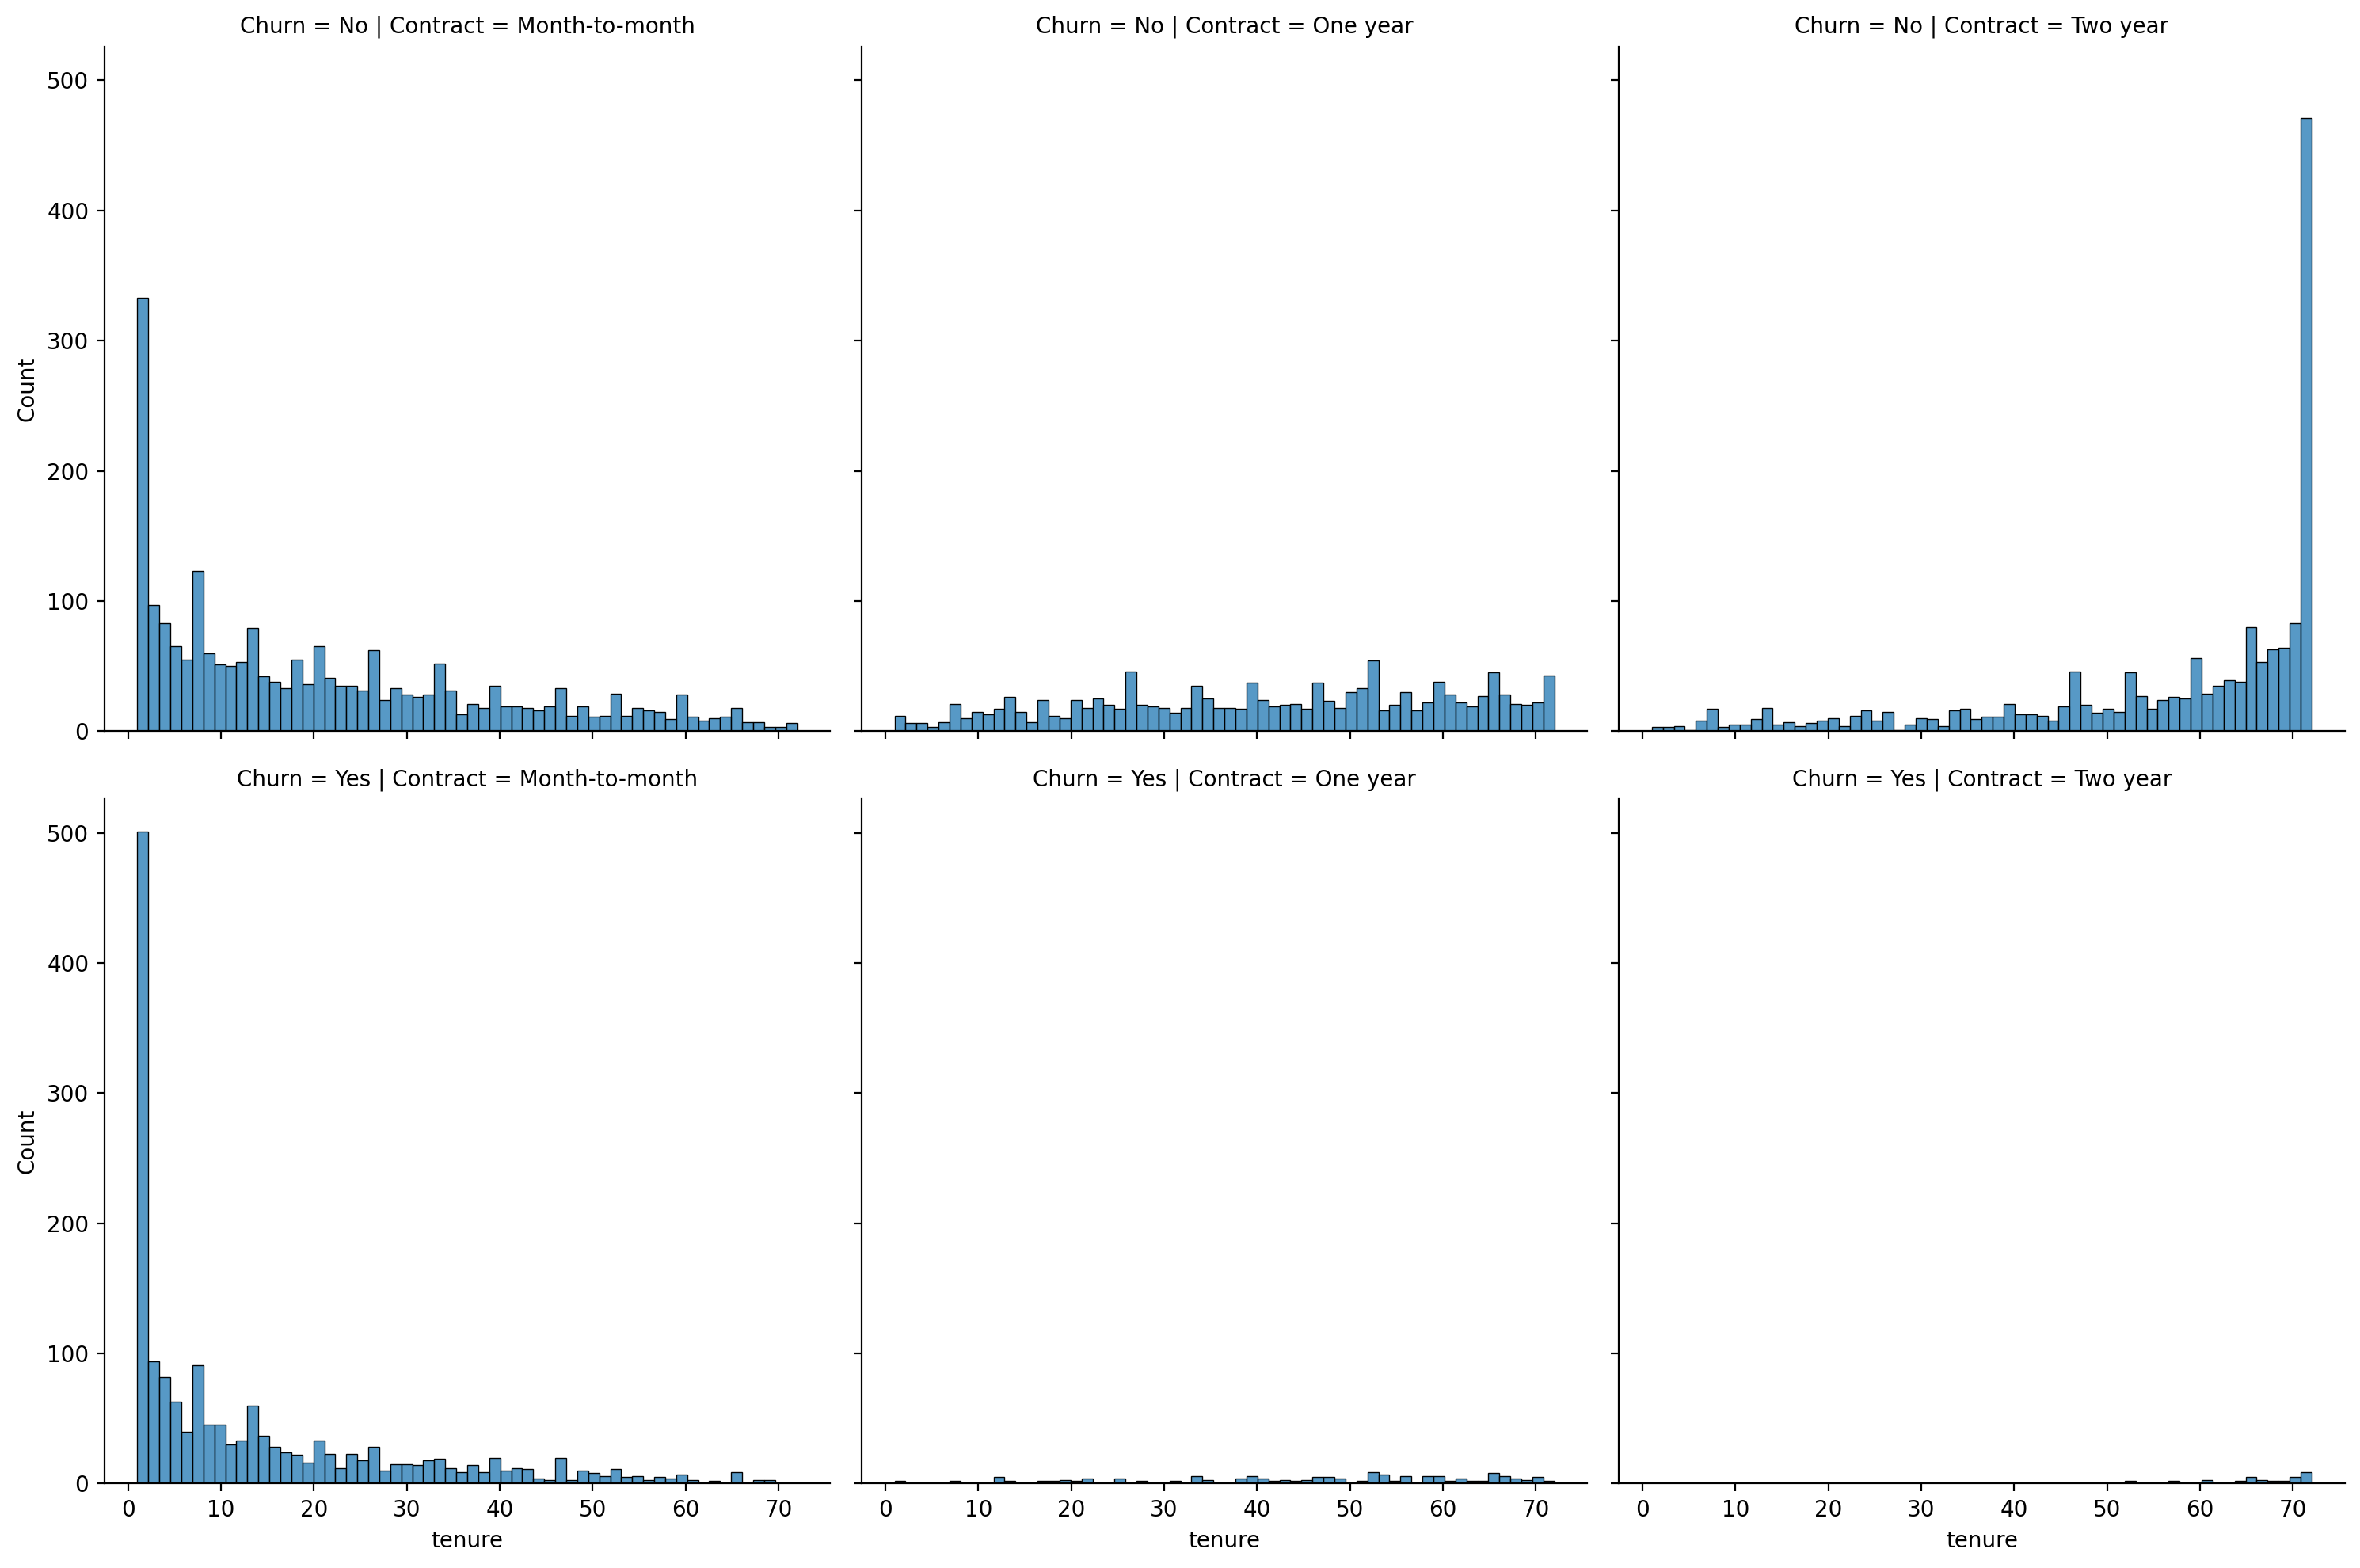

In [19]:
sns.displot(data = data, x = 'tenure', row = 'Churn', col = 'Contract', bins = 60)

To explore the relationship between customer spending and churn, we can create a scatter plot with `MonthlyCharges`
	•	The y-axis represents Total Charges
	•	The hue represents Churn status (Yes or No)

Customers with a low total charge are more likely to churn. Customers with higher total charges tend to stay longer and are less likely to churn. This also aligns with earlier findings from the tenure analysis the longer a customer stays, the higher their total charge, and the lower the chance of churn. However, as monthly charges increase, the likelihood of churn also increases. This suggests that high monthly costs may be a churn risk factor, especially for new or short-tenure customers.

<Axes: xlabel='MonthlyCharges', ylabel='TotalCharges'>

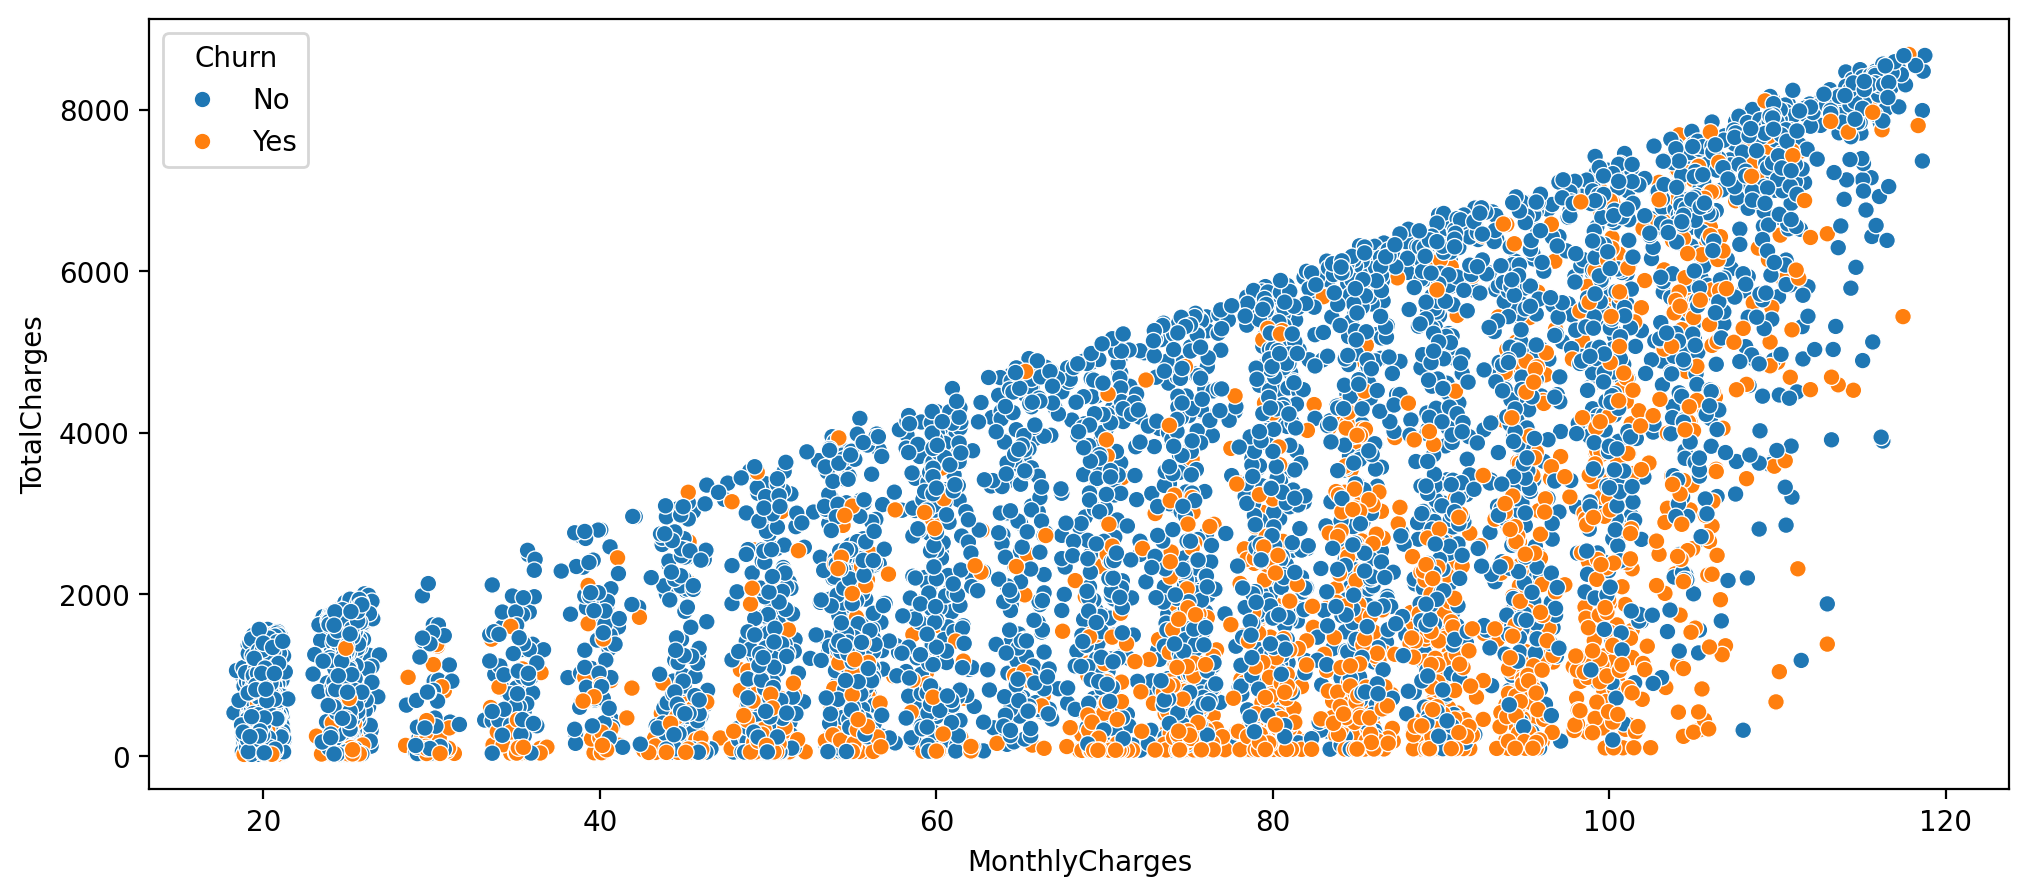

In [20]:
plt.figure(figsize = (12,5))
sns.scatterplot(x = 'MonthlyCharges', y = 'TotalCharges', hue = 'Churn', data = data)

The churn percentage (also called the churn rate) represents the proportion of customers who have left the company within a given period.

$$
\text{Churn Percentage} = \frac{\text{Number of Churned Customers}}{\text{Total Number of Customers}} \times 100
$$

This metric gives us am understanding of how many customers are leaving relative to the total customer base. We can analyze churn percentage for each month and see how it changes. Let’s take the first month as an example. Total customers is 613 and customers who churned in first month is 380. 

$$
\left( \frac{380}{613} \right) \times 100 = 61.99\%
$$

This is a very high churn rate in the first month. Our main goal is to minimize this churn, and examine how it changes as the `tenure` increases. By understanding which features contribute to churn, we can take action to improve retention.

In [21]:
data['tenure'].value_counts() 

tenure
1     613
72    362
2     238
3     200
4     176
     ... 
38     59
28     57
39     56
44     51
36     50
Name: count, Length: 72, dtype: int64

In [22]:
data[data['tenure'] == 1]['Churn'].value_counts()['Yes']

np.int64(380)

In [23]:
380 / 613 * 100

61.99021207177814

To analyze how customer churn changes over time, we calculate the churn percentage for each value of `tenure`, which represents the number of months a customer has been with the company. We start by creating an empty list called `churn_rate`, which will store the churn percentage for each month. Then, using a for loop from 1 to 72, first filter the data for customers with tenure equal to i months, next count the number of churned customers `Yes` and total customers and calculate churn percentage. Final step is to append the result to the `churn_rate` list.

In [24]:
churn_rate = [ ]

In [25]:
for i in range(1, 73):
    data[data['tenure'] == i]['Churn'].value_counts()
    churn = data[data['tenure'] == i]['Churn'].value_counts()['Yes'] / np.sum(data[data['tenure'] == i]['Churn'].value_counts().values) * 100
    churn_rate.append(churn)

In [26]:
churn_rate_df = pd.DataFrame(index = range(1,73), data = churn_rate)

Now that we have calculated the churn percentages for each month and stored them in the `churn_rate` list, we visualize these values, we observe a clear trend as the `tenure` increases, the churn percentage decreases. In particular, for customers with tenure between 60 and 70 months, the churn rate stabilizes around 10%. This is a relatively low churn rate and indicates customer loyalty over time. So to retain more customers and reduce overall churn, our strategy should aim to increase customer tenure.

Text(0, 0.5, 'Churn Percentage')

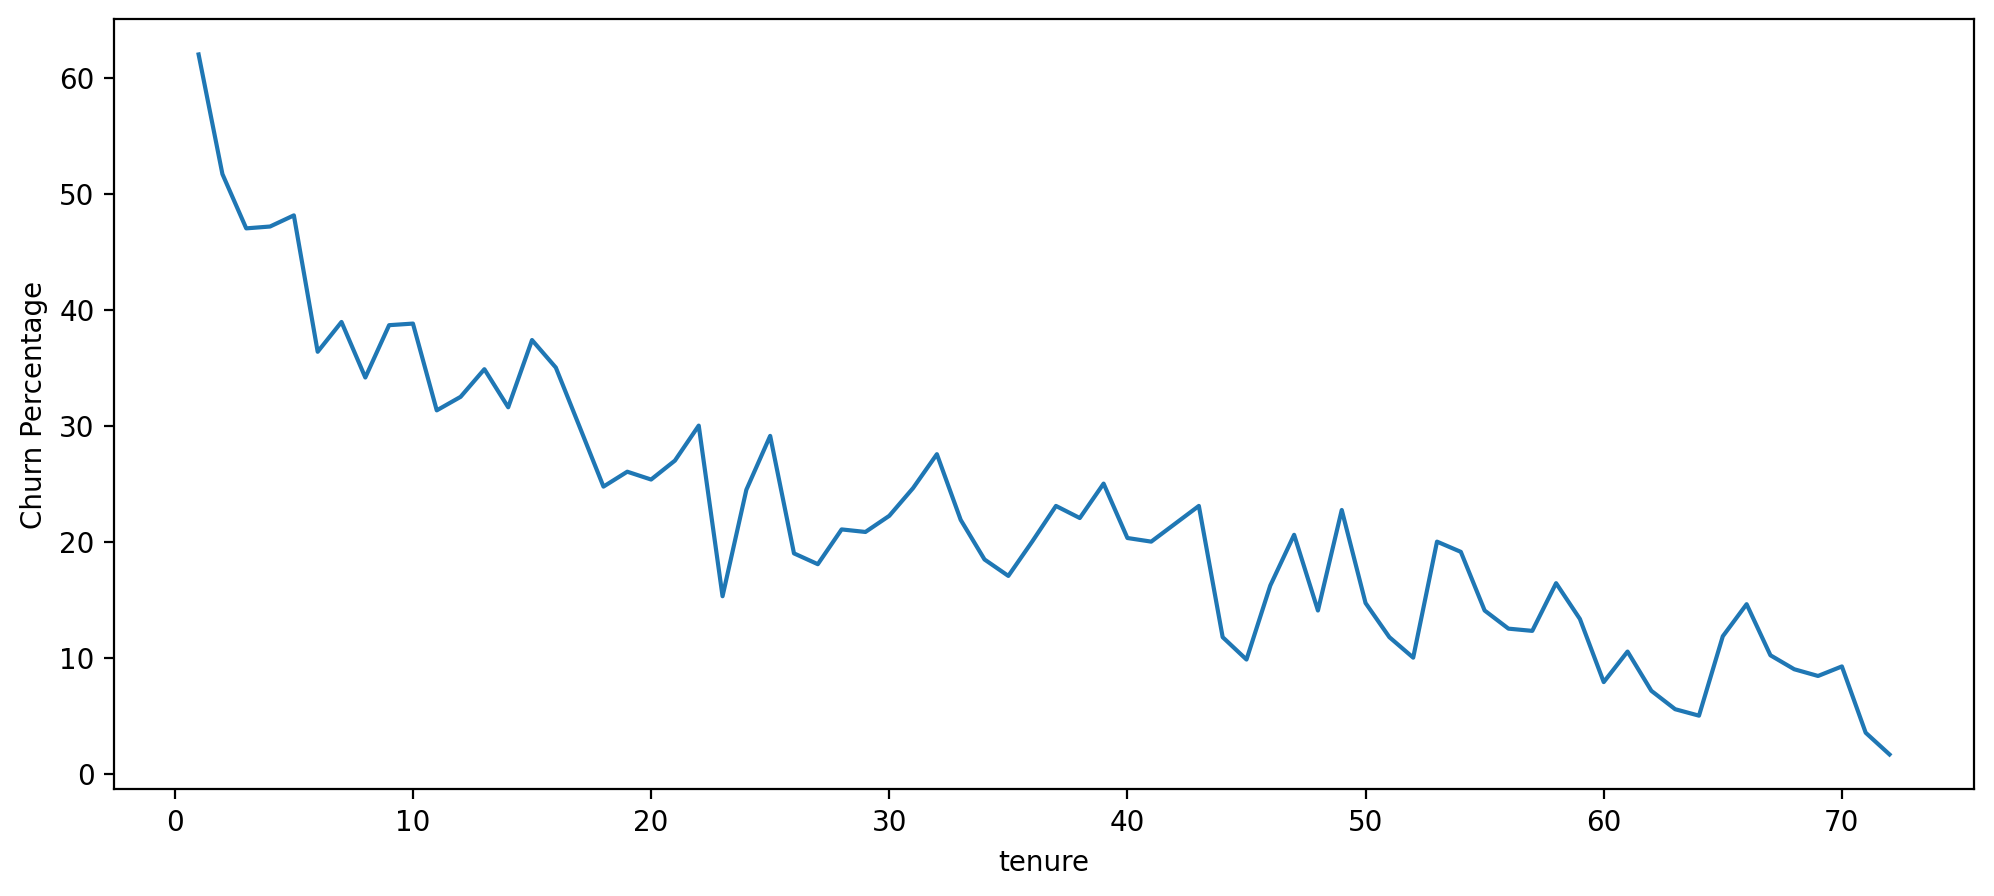

In [27]:
plt.figure(figsize = (12, 5))
plt.plot(churn_rate_df)
plt.xlabel('tenure')
plt.ylabel('Churn Percentage')

## 2.3 Cohort Analysis of Customer Churn

Cohort – a group of people who share a common characteristic over a specific time period. Cohort analysis is a type of behavioral analytics that breaks down data into cohorts based on shared characteristics typically by the time when they first interacted with a product or service. For example, in a churn analysis, we can create cohorts based on the month a customer joined and then track how each cohort behaves over time such as how many customers from each group churned after a few months.

In [28]:
cohorts = data['tenure'].astype(str)

In [29]:
cohorts

0        1
1       34
2        2
3       45
4        2
        ..
7027    24
7028    72
7029    11
7030     4
7031    66
Name: tenure, Length: 7032, dtype: object

We can create cohorts in different ways and one way is to divide customers by tenure. The loop below, where divide users based on their tenure into four segments: 	0-12 Months, 12-24 Months, 24-48 Months, and Over 48 Months. This loop takes a real-valued numerical feature (the number of months in tenure) and converts it into a categorical feature by assigning string labels. Each user is placed into one of the four cohorts based on how long they have been with the service.

In [30]:
for i in range(0, 7032):
    if (1 <= data['tenure'][i] <= 12):
        cohorts[i] = ('0-12 Months')
    elif (13 <= data['tenure'][i] <= 24):
        cohorts[i] = ('12-24 Months')
    elif (24 <= data['tenure'][i] <= 48):
        cohorts[i] = ('24-48 Months')
    else: 
        cohorts[i] = ('Over 48 Months')

In [31]:
cohorts

0          0-12 Months
1         24-48 Months
2          0-12 Months
3         24-48 Months
4          0-12 Months
             ...      
7027      12-24 Months
7028    Over 48 Months
7029       0-12 Months
7030       0-12 Months
7031    Over 48 Months
Name: tenure, Length: 7032, dtype: object

In [32]:
cohorts.shape

(7032,)

In [33]:
cohorts.value_counts()

tenure
Over 48 Months    2239
0-12 Months       2175
24-48 Months      1594
12-24 Months      1024
Name: count, dtype: int64

This new column can be added to the dataset to compare it with target value `Churn` and other features. By grouping users into cohorts, we can observe how churn behavior varies across different customer lifespans.

In [34]:
cohorts = pd.DataFrame({'tenure': data['tenure'], 
                        'Tenure Cohort': cohorts, 
                        'TotalCharges': data['TotalCharges'], 
                        'MonthlyCharges': data['MonthlyCharges'],
                        'Churn': data['Churn'],
                        'Contract': data['Contract']
                       })

In [35]:
cohorts

,tenure,Tenure Cohort,TotalCharges,MonthlyCharges,Churn,Contract
0,1,0-12 Months,29.85,29.85,No,Month-to-month
1,34,24-48 Months,1889.50,56.95,No,One year
2,2,0-12 Months,108.15,53.85,Yes,Month-to-month
3,45,24-48 Months,1840.75,42.30,No,One year
4,2,0-12 Months,151.65,70.70,Yes,Month-to-month
...,...,...,...,...,...,...
7027,24,12-24 Months,1990.50,84.80,No,One year
7028,72,Over 48 Months,7362.90,103.20,No,One year
7029,11,0-12 Months,346.45,29.60,No,Month-to-month
7030,4,0-12 Months,306.60,74.40,Yes,Month-to-month


The scatter plot, visualize the relationship between `MonthlyCharges` and `TotalCharges`, with each customer color-coded based on their tenure cohort. We see that customers with longer tenure over 48 Months, which are red points, have naturally accumulated higher total charges over time. Customers with short tenure 0–12 Months, which are blue points mostly stay at the bottom of the chart, indicating lower total charges regardless of their monthly charges. The layered effect clearly shows how tenure contributes significantly to total charges, assuming monthly charges are constant.

<Axes: xlabel='MonthlyCharges', ylabel='TotalCharges'>

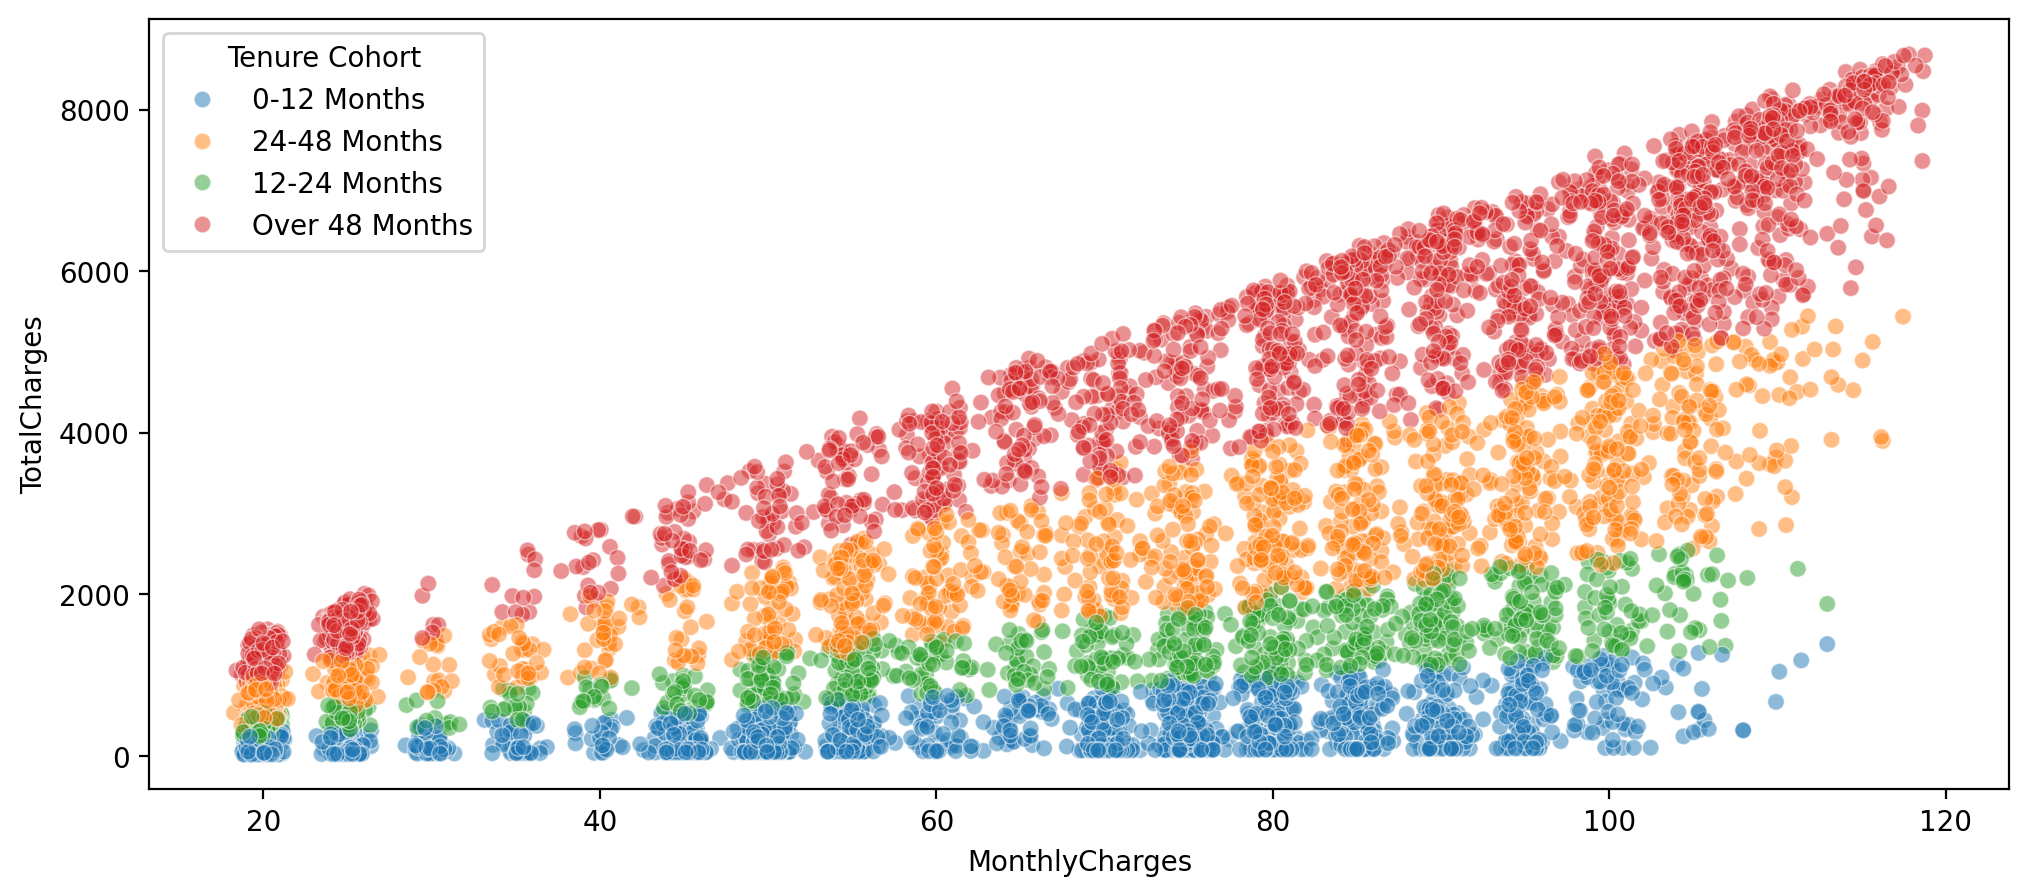

In [36]:
plt.figure(figsize = (12,5))
sns.scatterplot(x = 'MonthlyCharges', y = 'TotalCharges', hue = 'Tenure Cohort', alpha = 0.5, data = cohorts)

We can also analyze how churn rates vary across cohorts using countplots. By creating a countplot of churn status (Churn) within each of these cohorts, we can observe a clear trend: First after 12 months, the number of customers who leave become constant, however the number of customers who stayed increase. Customers who stayed over 48 months has the lowest churn rate. These are highly retained customers who demonstrate strong brand loyalty or satisfaction.

<Axes: xlabel='Tenure Cohort', ylabel='count'>

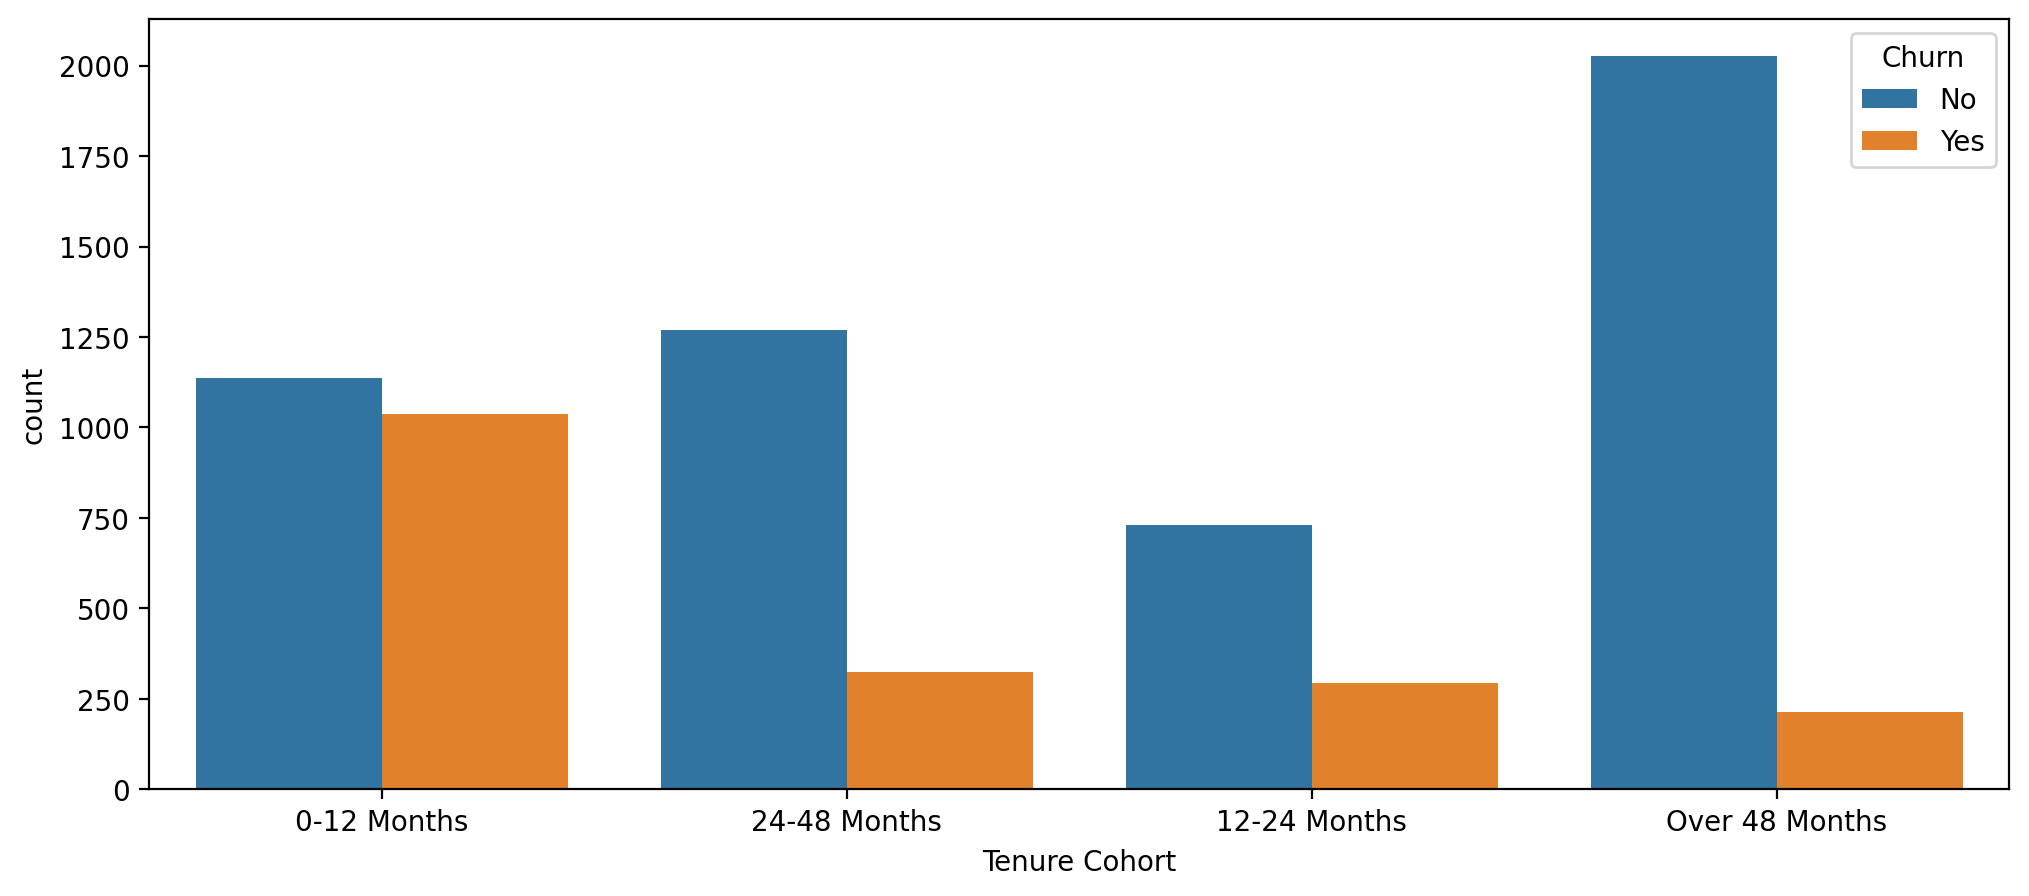

In [37]:
plt.figure(figsize = (12,5))
sns.countplot(x = 'Tenure Cohort', hue = 'Churn', data = cohorts)

The `Month-to-month` contracts show the highest churn, especially in the 0–12 month cohort. In contrast, `One year` and especially `Two year` contract customers have significantly lower churn rates, particularly in longer tenure groups. This suggests that customer loyalty improves over time, especially with longer-term contracts.

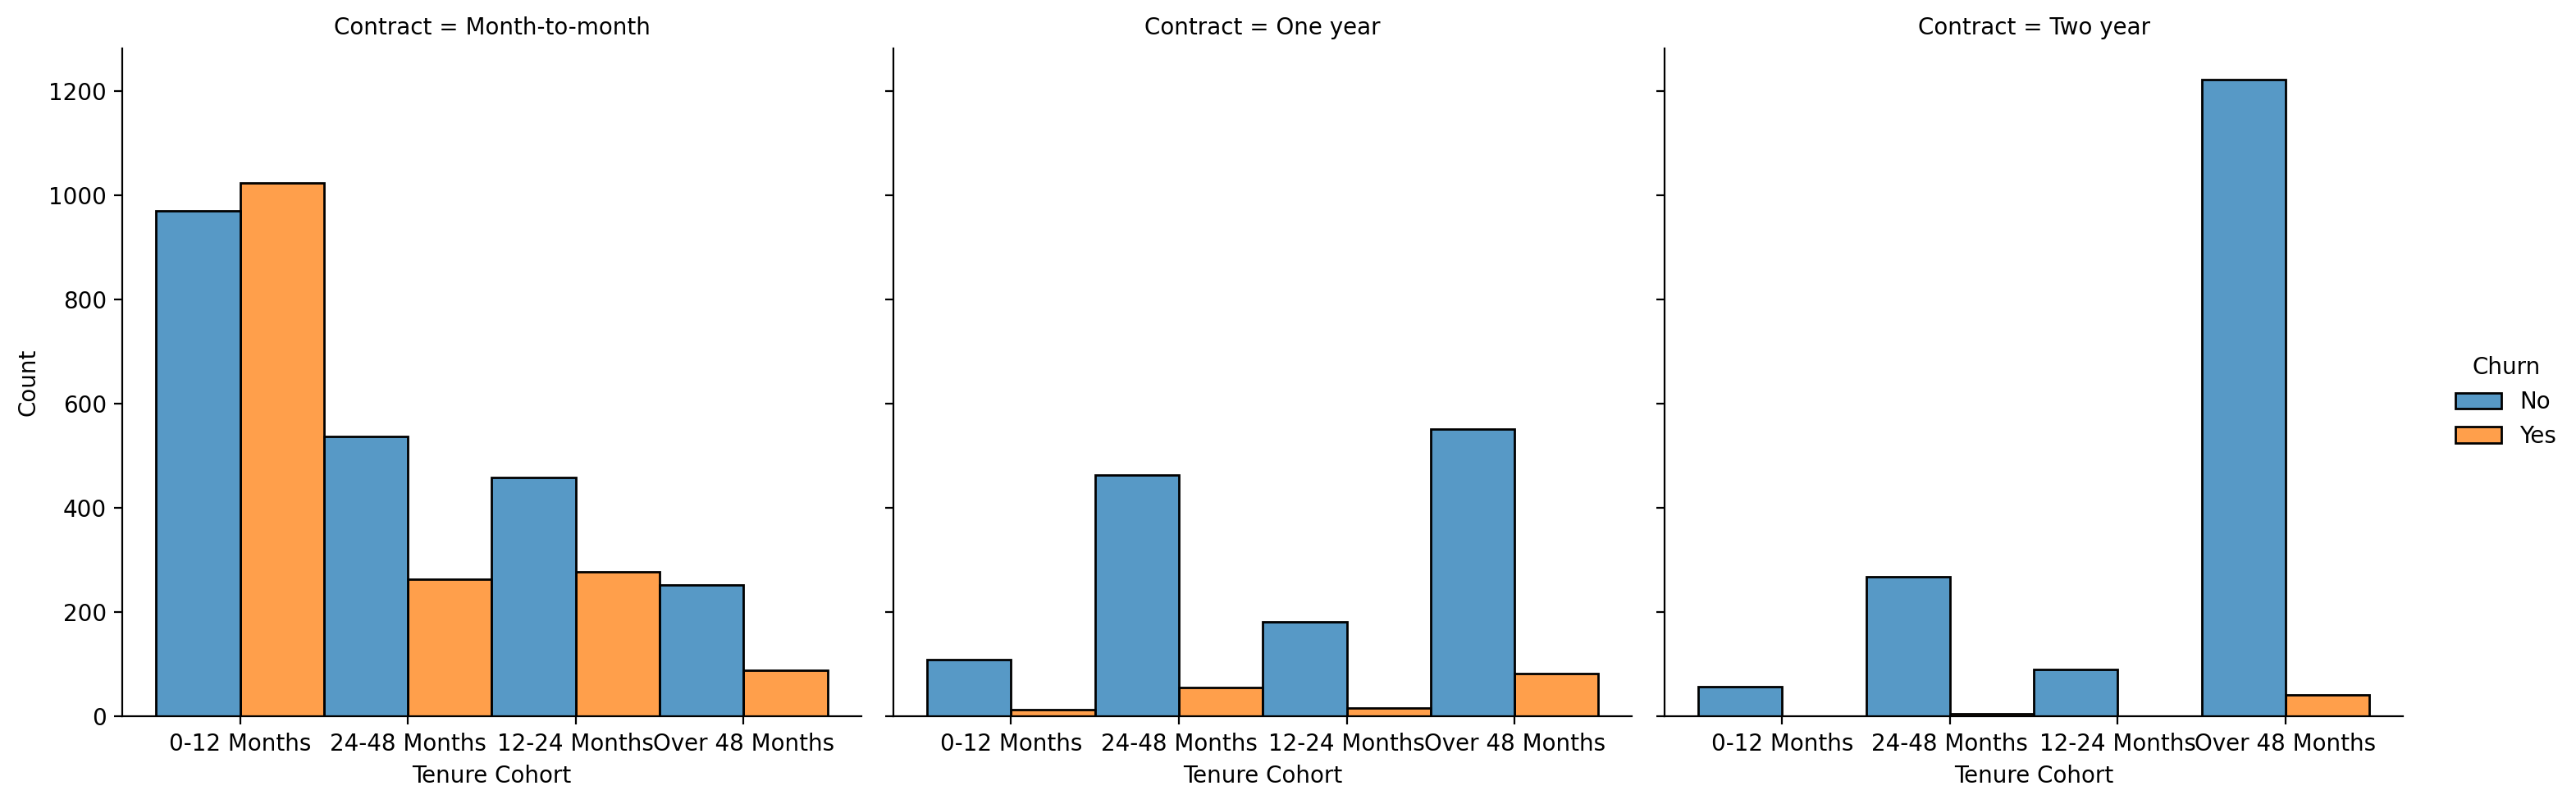

In [38]:
sns.displot(x = 'Tenure Cohort', col = 'Contract', hue = 'Churn', data = cohorts, multiple = 'dodge')

# 3. Model Training and Evaluation

In [39]:
X = pd.get_dummies(data.drop(['customerID', 'Churn'], axis = 1), drop_first = 1)

In [40]:
X

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,0,24,84.80,1990.50,True,True,True,True,False,True,...,False,True,False,True,True,False,True,False,False,True
7028,0,72,103.20,7362.90,False,True,True,True,False,True,...,False,True,False,True,True,False,True,True,False,False
7029,0,11,29.60,346.45,False,True,True,False,True,False,...,False,False,False,False,False,False,True,False,True,False
7030,1,4,74.40,306.60,True,True,False,True,False,True,...,False,False,False,False,False,False,True,False,False,True


In [41]:
y = data['Churn']

In [42]:
y

0        No
1        No
2       Yes
3        No
4       Yes
       ... 
7027     No
7028     No
7029     No
7030    Yes
7031     No
Name: Churn, Length: 7032, dtype: object

In [43]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.1, random_state = 101)

## 3.1 Decision Tree Model

To predict customer churn, I will compare the performance of three classification models. Our evaluation will be based on commonly used classification metrics: accuracy, precision, recall, and F1-score. First I will begin by training a Decision Tree Classifier on the dataset. This model is simple yet interpretable and often serves as a good baseline.

In [44]:
tree_model = DecisionTreeClassifier(random_state = 101)

In [45]:
tree_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=101)

In [46]:
tree_pred = tree_model.predict(X_test)

In [47]:
def plot_metrics(model, x_test, y_test):
    fig, axes = plt.subplots(1, 3, figsize = (18, 5))
    ConfusionMatrixDisplay.from_estimator(model, x_test, y_test, cmap = 'Blues', ax = axes[0])
    RocCurveDisplay.from_estimator(model, x_test, y_test, ax = axes[1])
    PrecisionRecallDisplay.from_estimator(model, x_test, y_test, ax = axes[2])
    axes[0].set_title('Confusion Matrix')
    axes[1].set_title('ROC Curve')
    axes[2].set_title('Precision-Recall Curve')
    plt.tight_layout()
    plt.show()

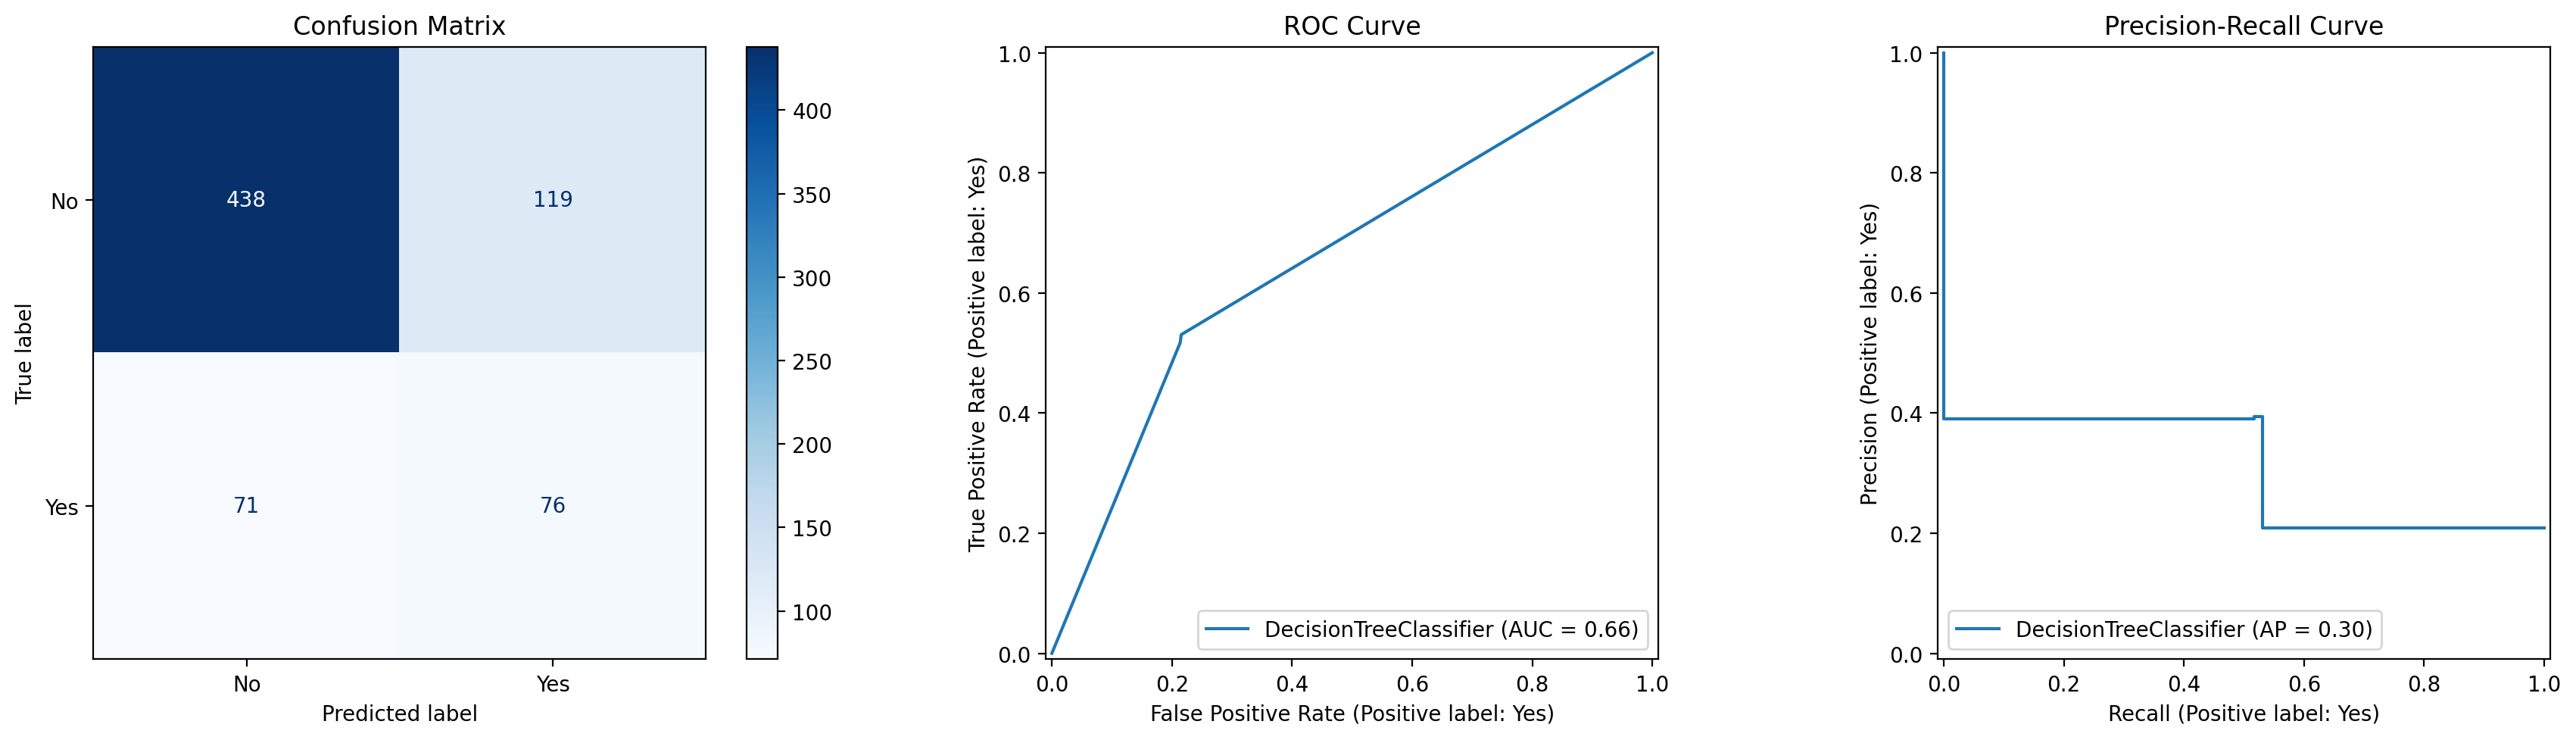

In [48]:
plot_metrics(tree_model, X_test, y_test)

Based on the ROC, Precision-Recall curve and the classification report, the Decision Tree model does not perform very well, with an accuracy of approximately 73%. This relatively low performance may be due to overfitting. To investigate this further, we can analyze the structure of the tree by visualizing it.

In [49]:
print(classification_report(y_test, tree_pred))

              precision    recall  f1-score   support

          No       0.86      0.79      0.82       557
         Yes       0.39      0.52      0.44       147

    accuracy                           0.73       704
   macro avg       0.63      0.65      0.63       704
weighted avg       0.76      0.73      0.74       704



The tree is extremely overfitted, it has a maximum depth greater than 25. This excessive depth causes the model to perform poorly on unseen data, even if it fits the training data well. To address this, we can control the complexity of the tree using the `max_depth` parameter. I will retrain the model by setting `max_depth = 6` to reduce overfitting and improve generalization.

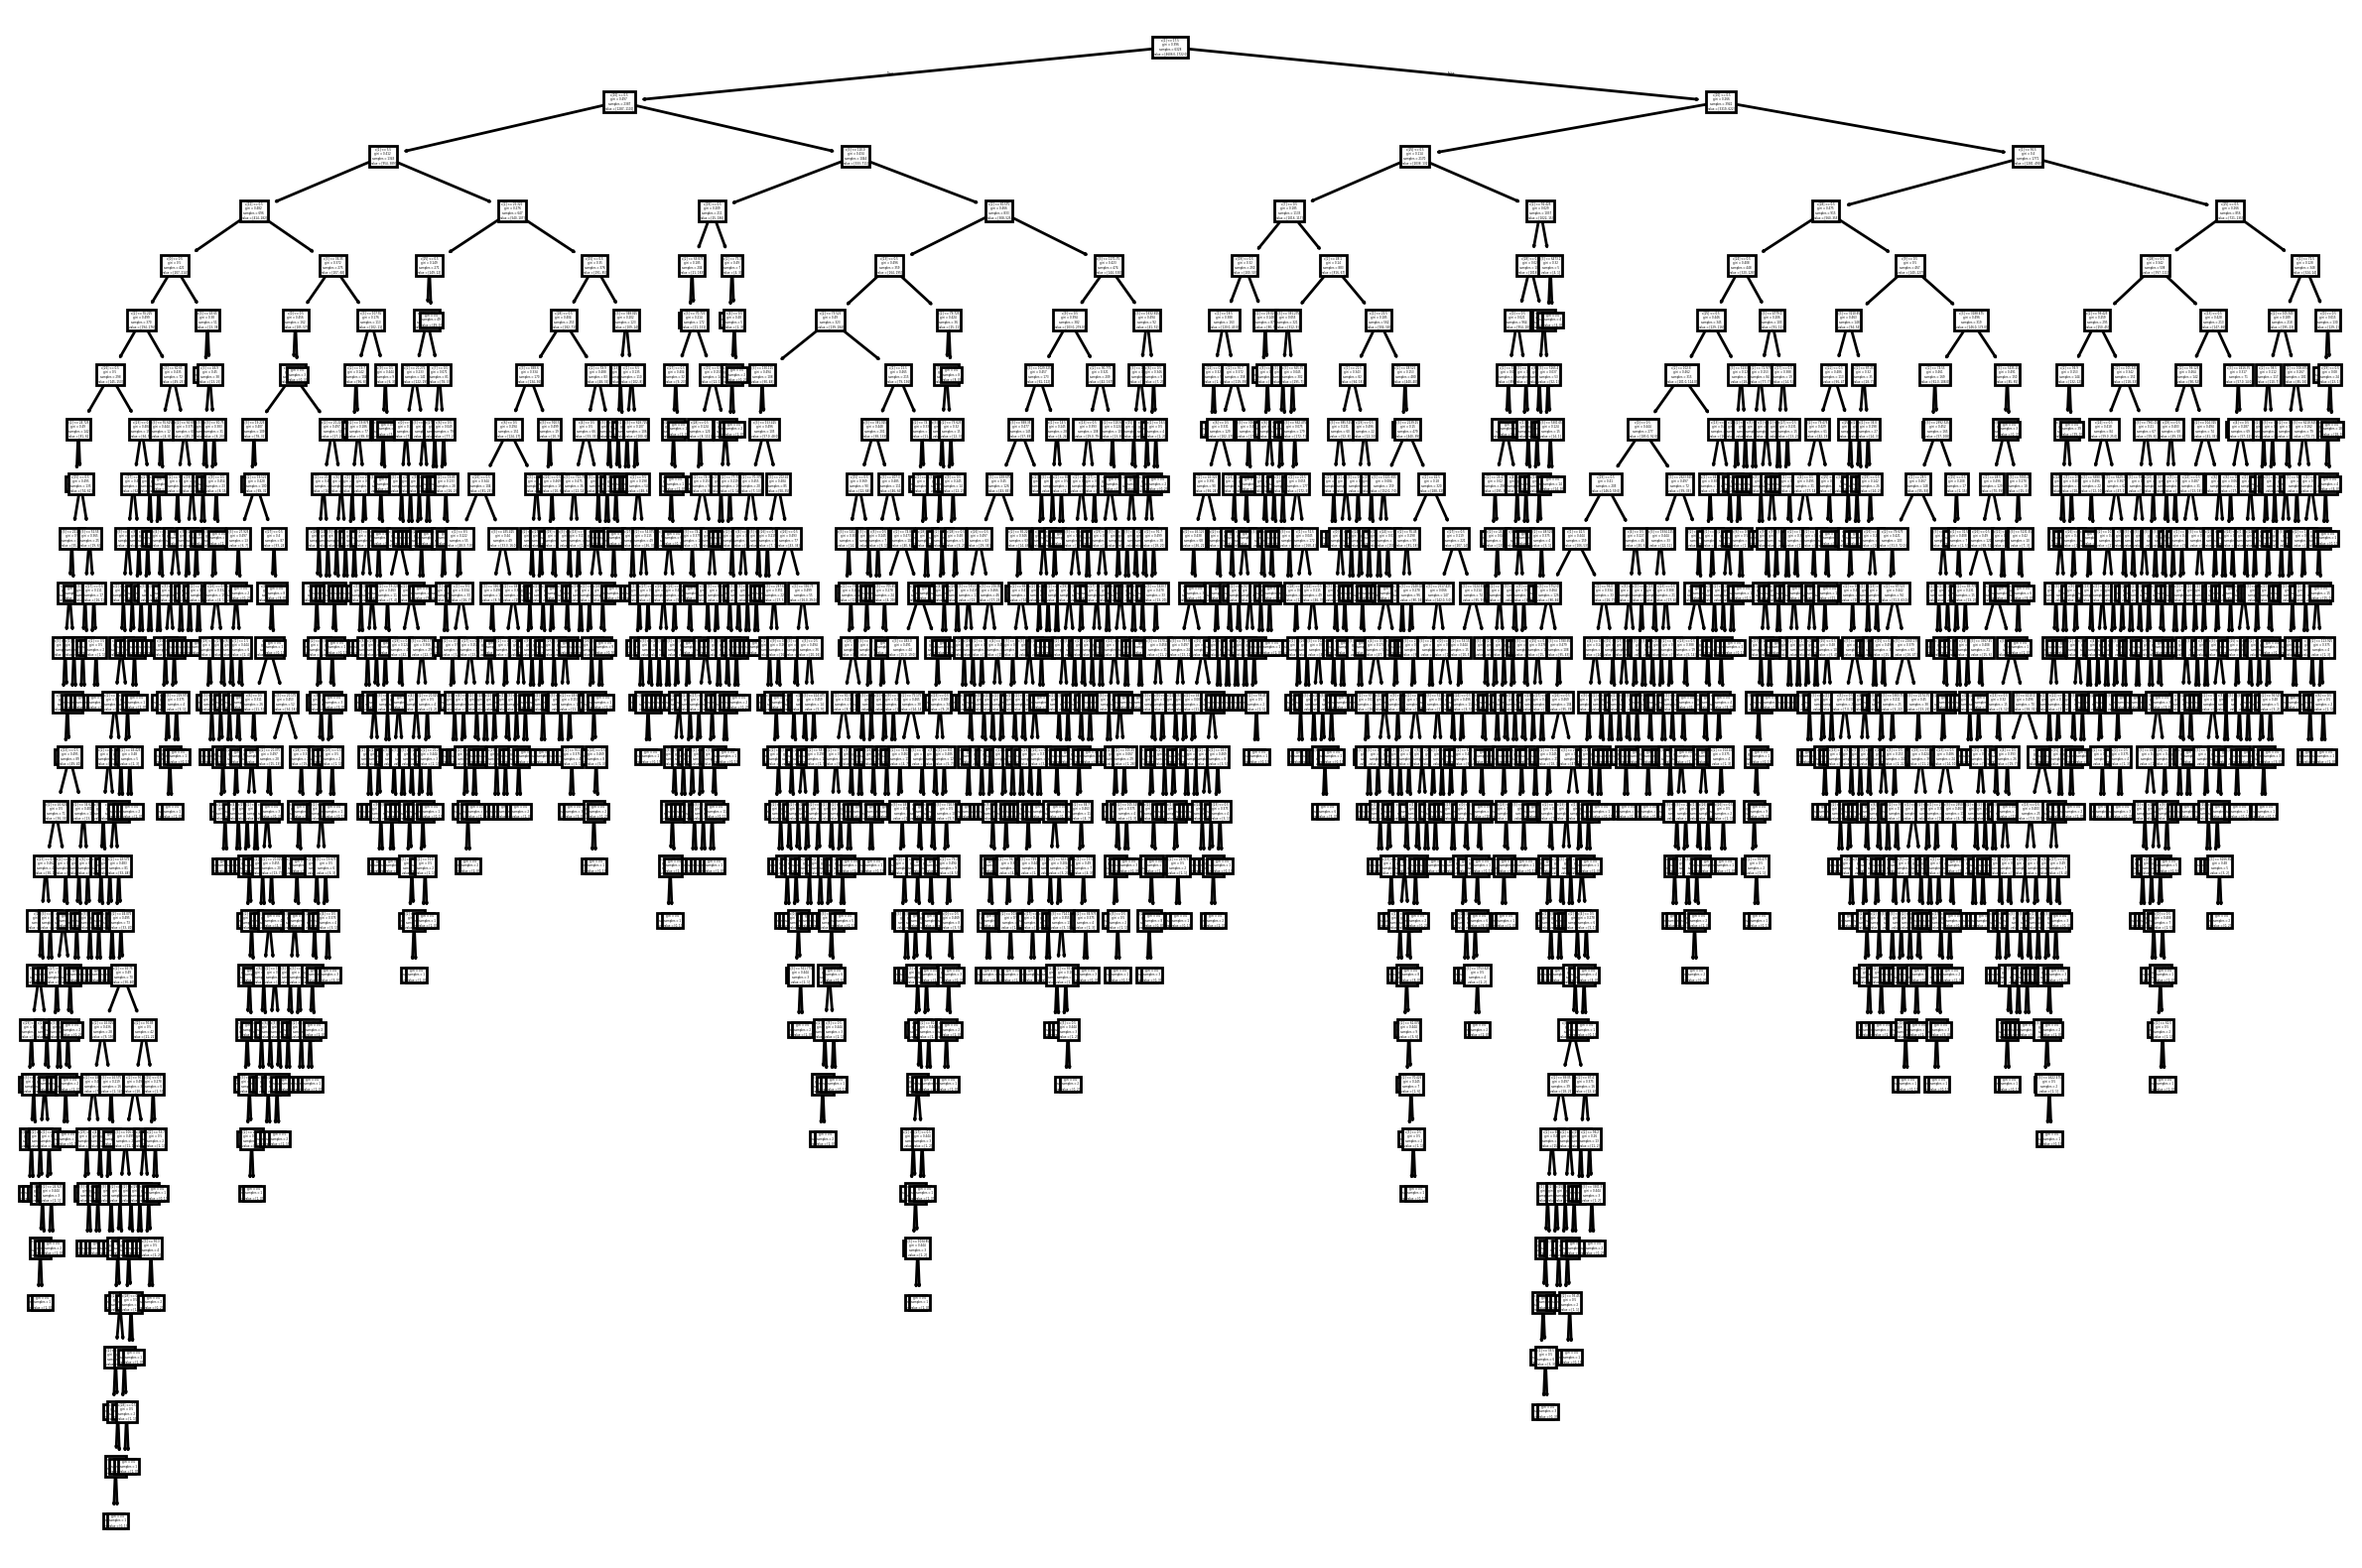

In [50]:
plt.figure(figsize = (15,10))
plot_tree(tree_model);

In [51]:
pruned_tree = DecisionTreeClassifier(max_depth = 6, random_state = 101)

In [52]:
pruned_tree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=6, random_state=101)

In [53]:
pruned_pred = pruned_tree.predict(X_test)

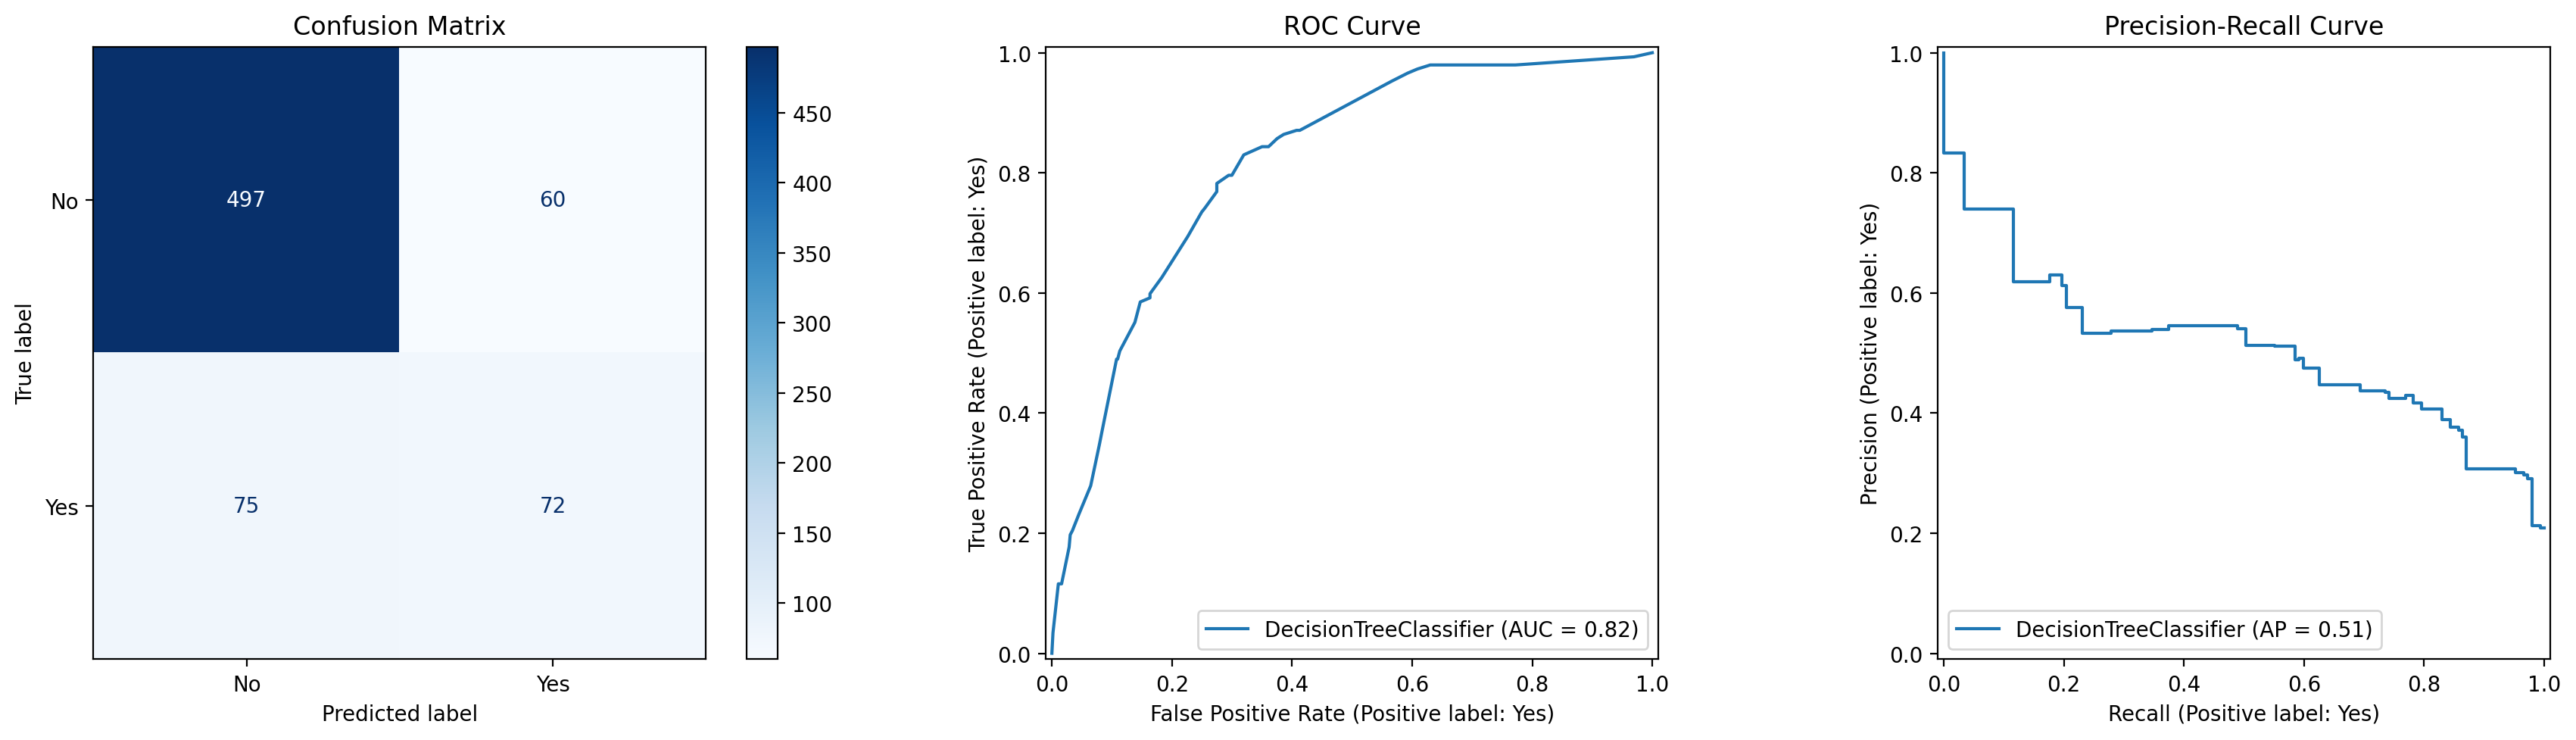

In [54]:
plot_metrics(pruned_tree, X_test, y_test)

As we can see, after pruning the tree by setting `max_depth = 6`, the model achieved an accuracy of 81%, which is better than the previous result and the graphs became more smoother. This confirms that controlling the tree depth helps prevent overfitting.

In [55]:
print(classification_report(y_test, pruned_pred))

              precision    recall  f1-score   support

          No       0.87      0.89      0.88       557
         Yes       0.55      0.49      0.52       147

    accuracy                           0.81       704
   macro avg       0.71      0.69      0.70       704
weighted avg       0.80      0.81      0.80       704



## 3.2 Feature Importance

Using the `feature_importances_` attribute of the decision tree model, we can analyze how important each feature is in making predictions. The index of each importance value corresponds to the index of the respective feature in the training dataset train dataset `X`. By visualizing these importances, we gain insights into which variables have the most influence on the model’s decisions.

In [56]:
pruned_tree.feature_importances_

array([0.01082504, 0.42391407, 0.04229274, 0.06799038, 0.00123697,
       0.        , 0.        , 0.        , 0.00785158, 0.01243191,
       0.31406016, 0.        , 0.02628952, 0.00837585, 0.        ,
       0.00534132, 0.        , 0.        , 0.        , 0.00786752,
       0.        , 0.        , 0.        , 0.        , 0.01002118,
       0.02706543, 0.        , 0.        , 0.03443632, 0.        ])

In [57]:
X.columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object')

In [58]:
features = pd.DataFrame(index = X.columns, data = pruned_tree.feature_importances_, columns = ['Importance'])

In [59]:
features = features.reset_index()

In [60]:
features = features.sort_values('Importance')

In our case, the feature `tenure` as we find out in exploratory data analysis, turned out to be the most important one. This means that the decision tree begins its first split at the root node using tenure. However, this result is influenced by the `random_state = 101` parameter we set when initializing the model. Decision Trees in scikit-learn can behave differently depending on the value of `random_state`, because when there are multiple equally good splits, the algorithm randomly chooses among them. This means that feature importance is not fixed—changing the `random_state` may result in a different tree structure, and therefore, different features being selected as more or less important. So, although in our current model tenure appears to be the most influential feature, this is not a universal truth. In different runs or settings, other features may take precedence. This stochastic nature of tree-based models is one of the reasons why ensemble methods like Random Forests are often preferred—they average out these variances and provide more stable feature importance values.

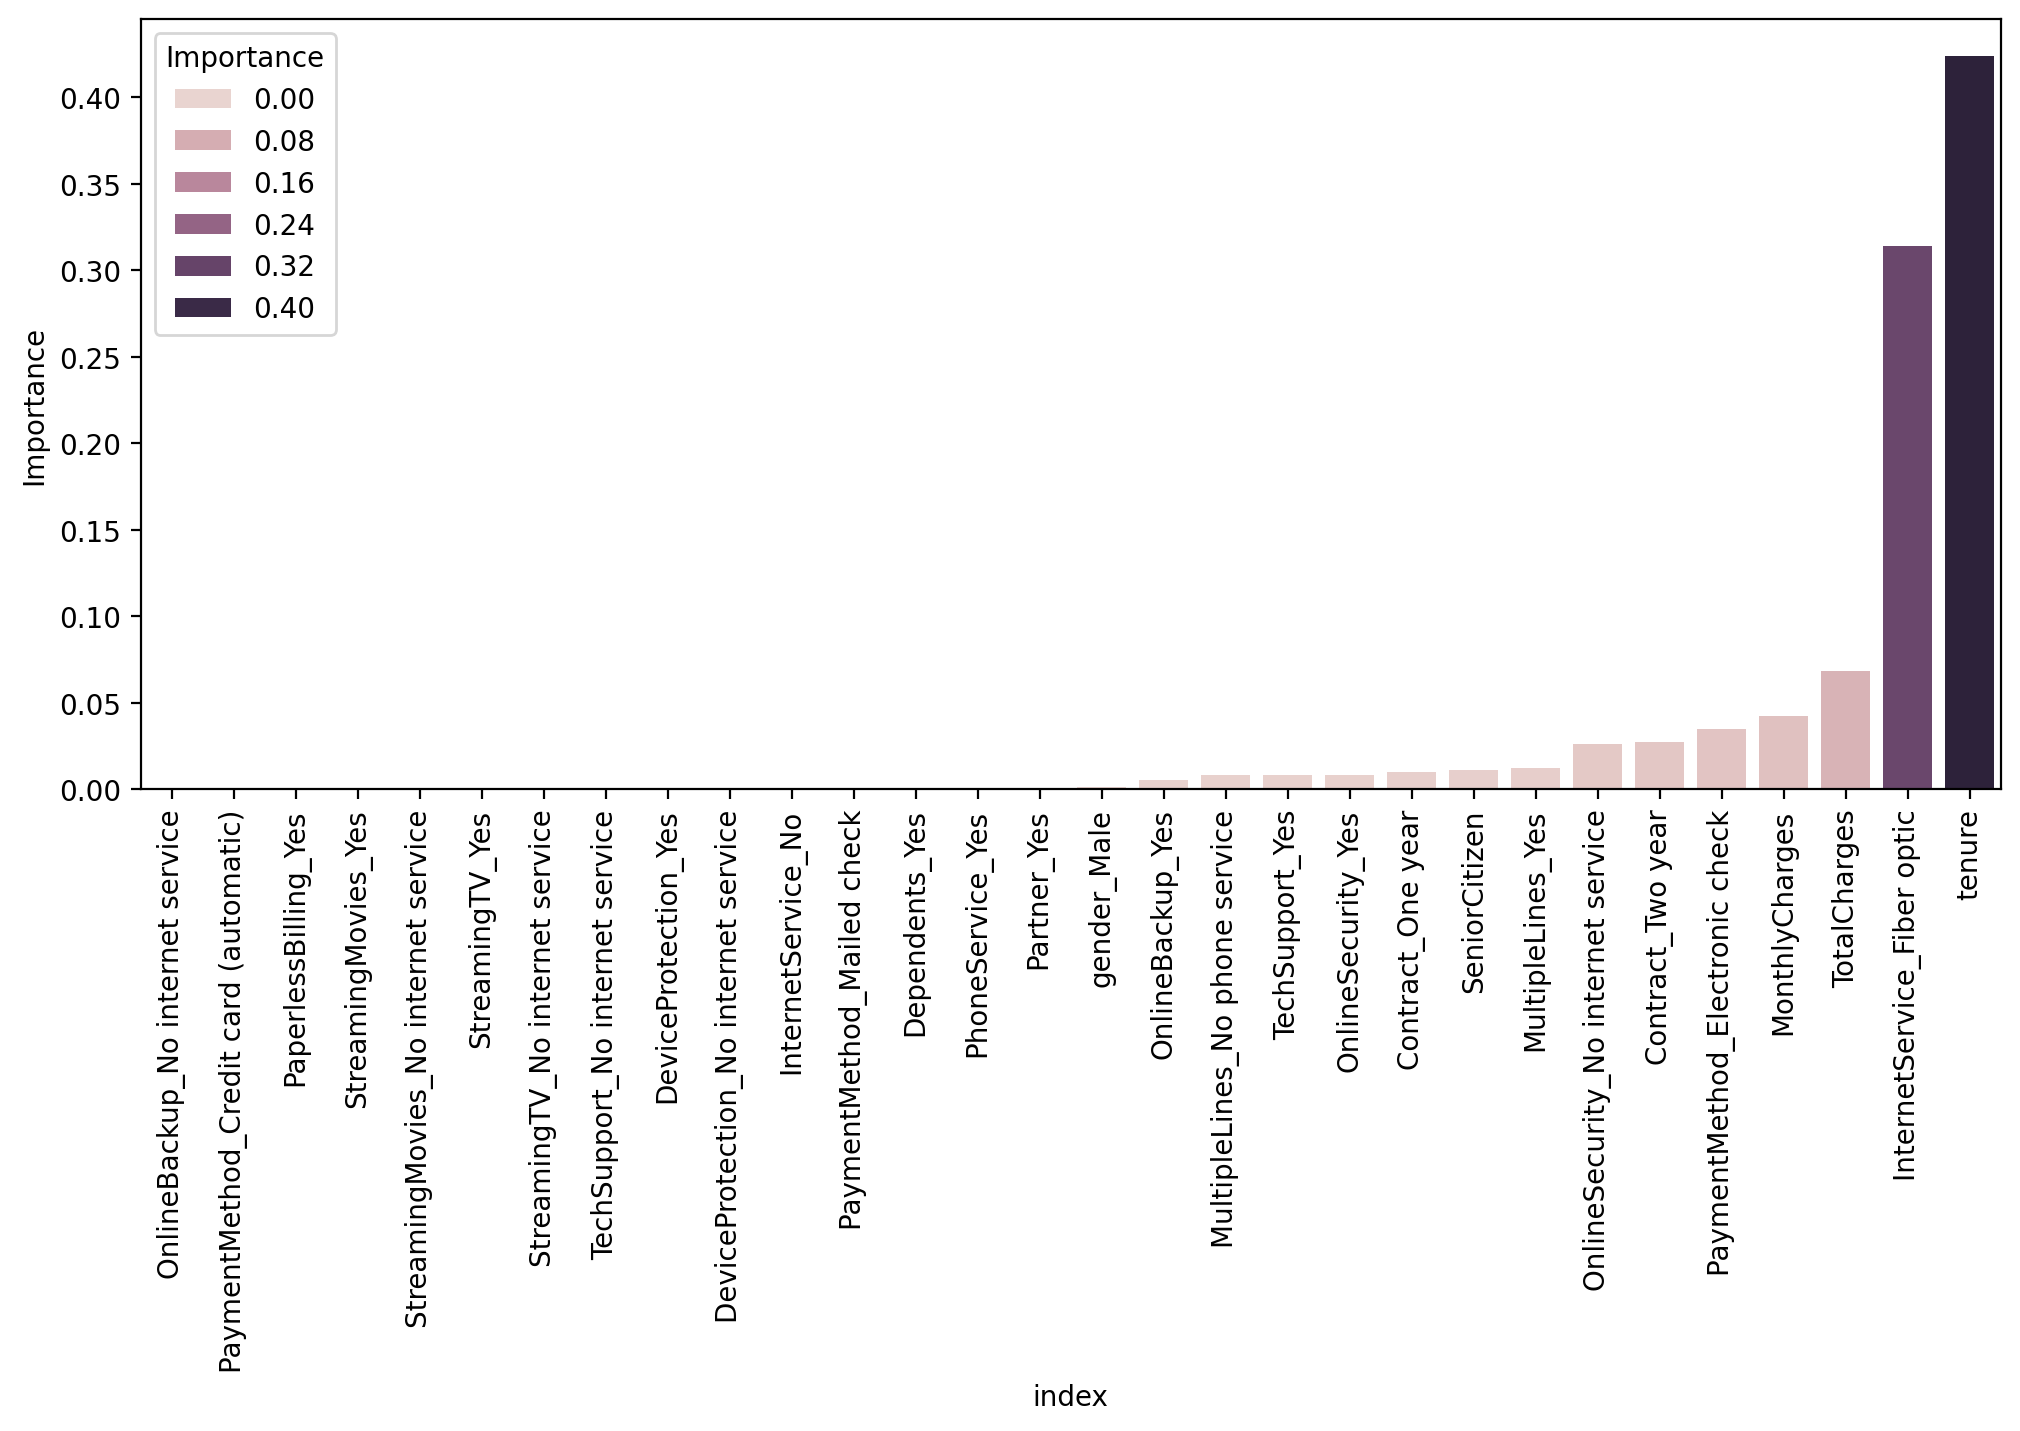

In [61]:
plt.figure(figsize = (12, 5))
sns.barplot(x = features['index'], y = 'Importance', hue = 'Importance', data = features)
plt.xticks(rotation = 90)
plt.show()

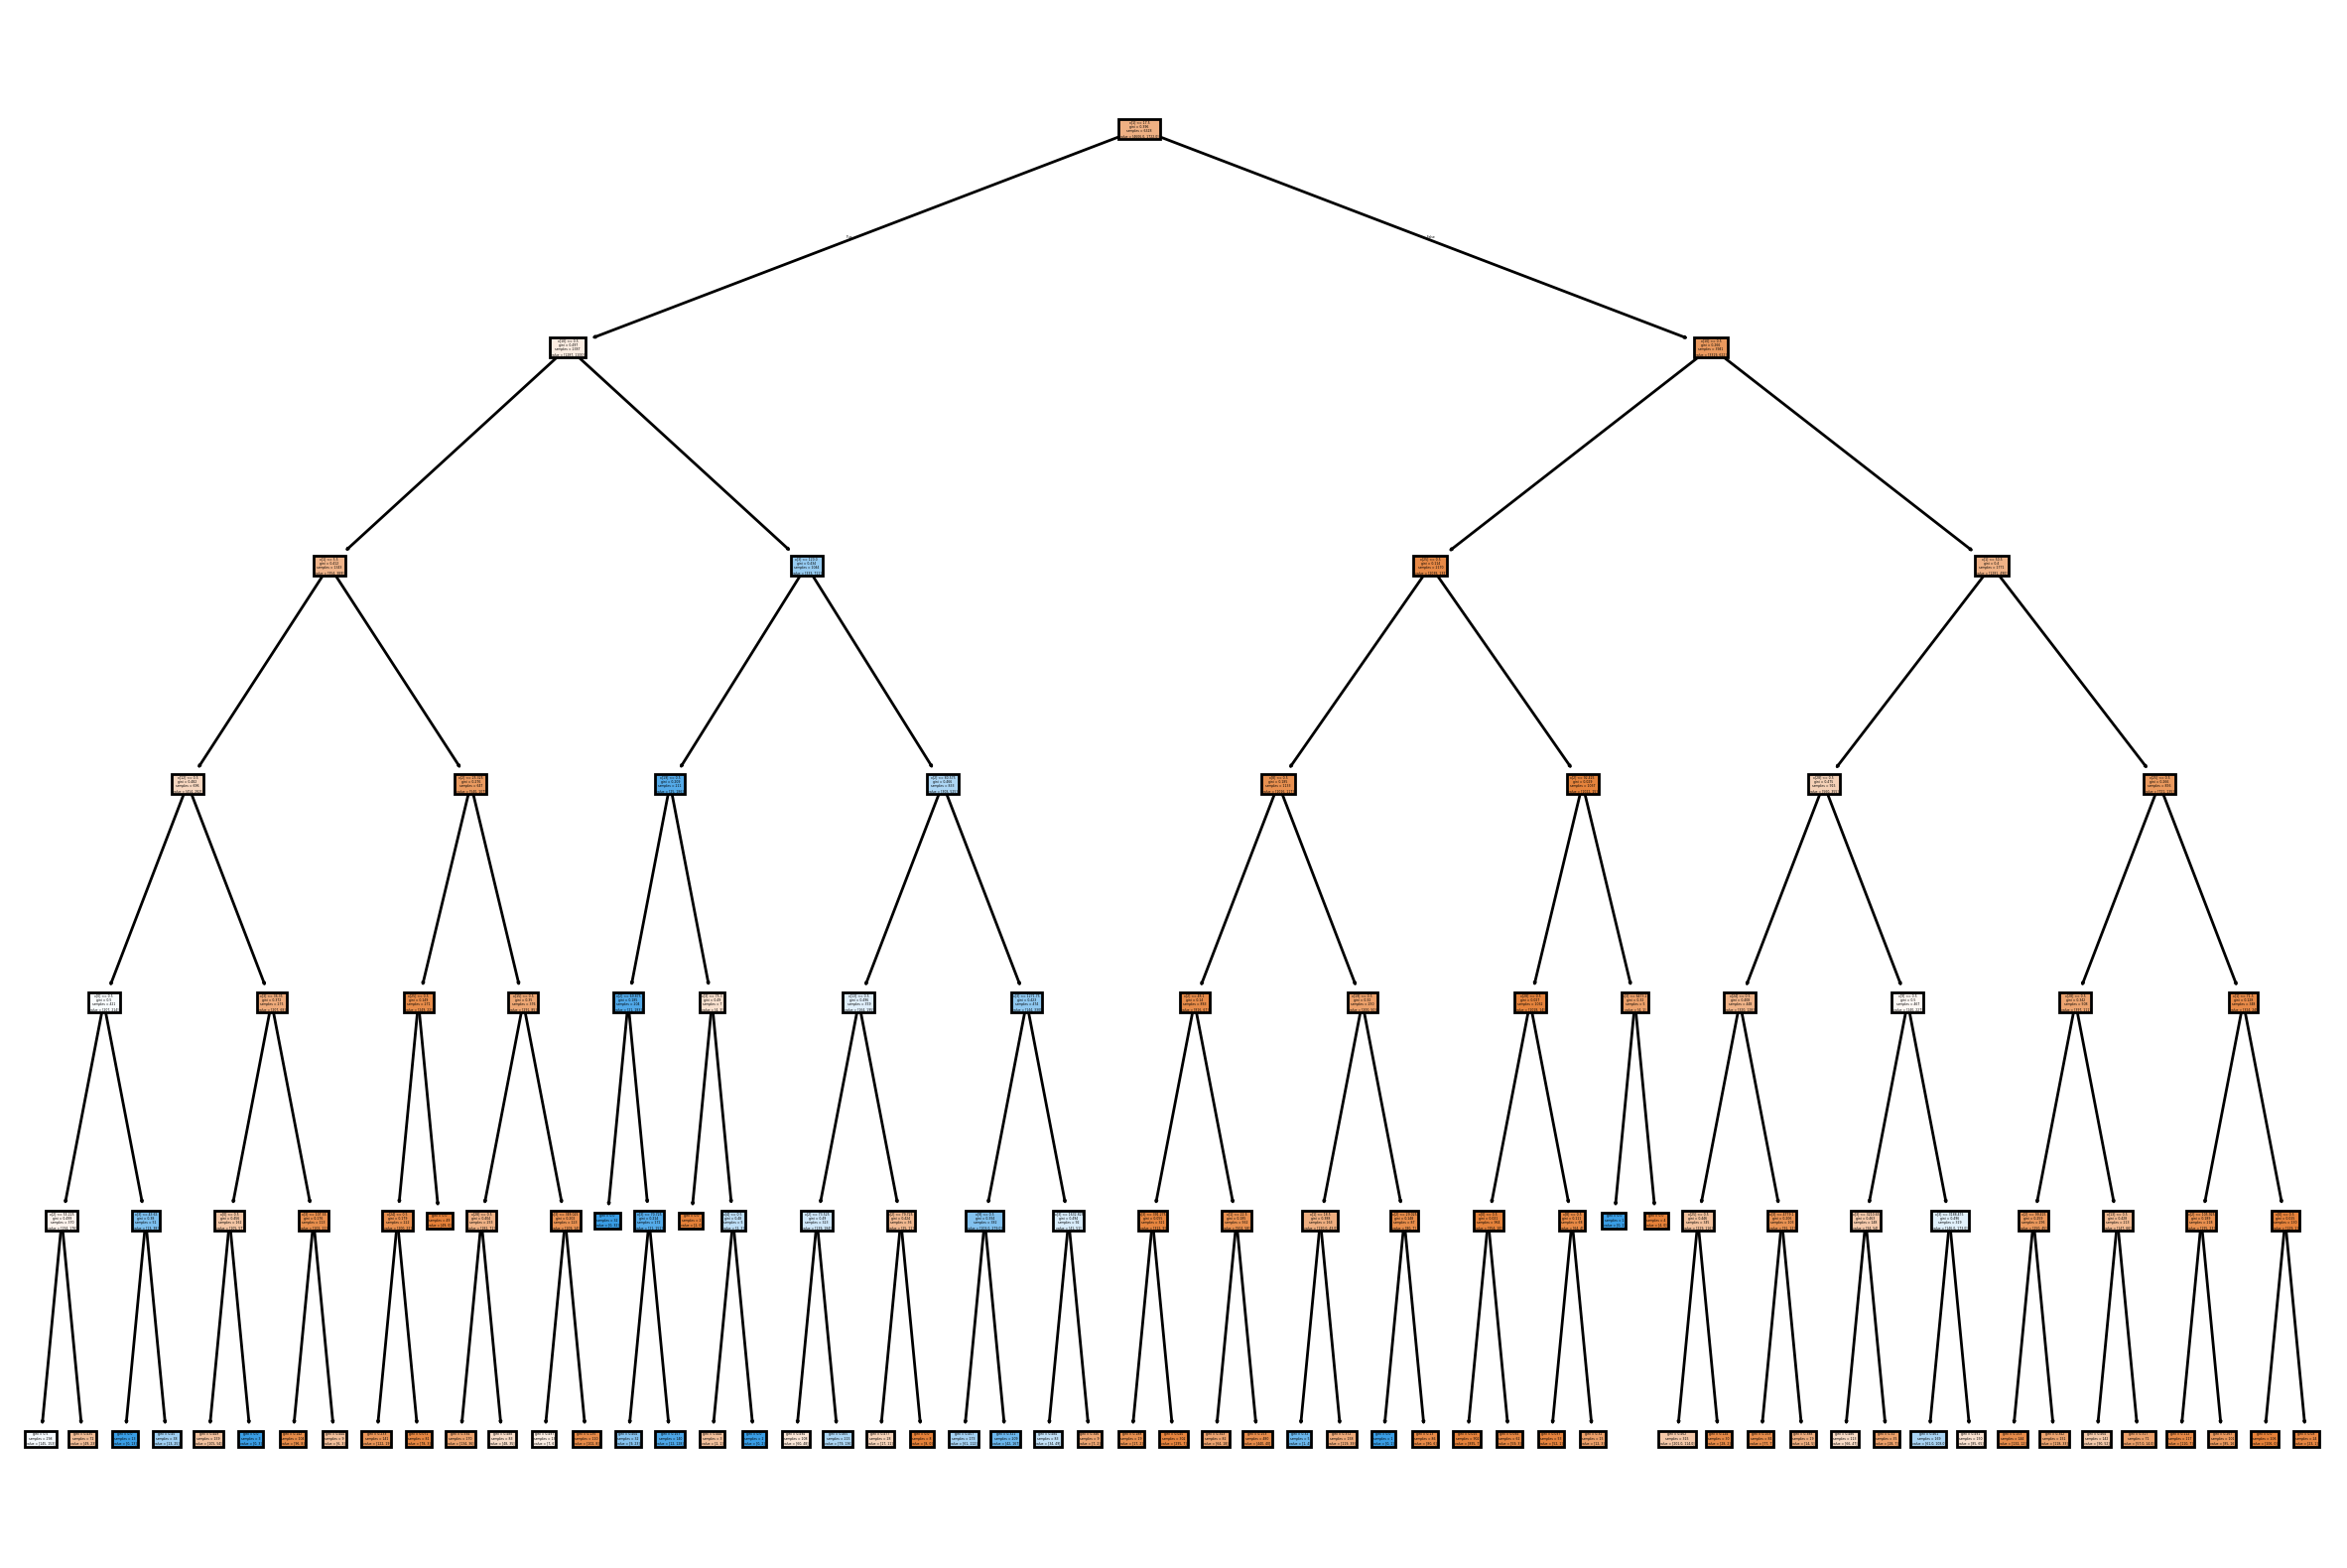

In [62]:
plt.figure(figsize = (15, 10))
plot_tree(pruned_tree, filled = True);

## 3.3 Random Forest

The next model is Random Forest, which is an ensemble method that builds and combines multiple decision trees to make more robust predictions. Unlike a single decision tree, Random Forest aggregates the outputs of several trees, reducing the risk of overfitting and improving generalization. One of the key parameters in this model is `n_estimators`, which determines the number of trees in the forest. A higher number generally leads to better performance, but it also increases computation time. The optimal value for this parameter often depends on the specific dataset and available computational resources. For our case i will set `n_estimators = 200`. 

In [63]:
forest_model = RandomForestClassifier(n_estimators = 200)

In [64]:
forest_model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200)

In [65]:
forest_pred = forest_model.predict(X_test)

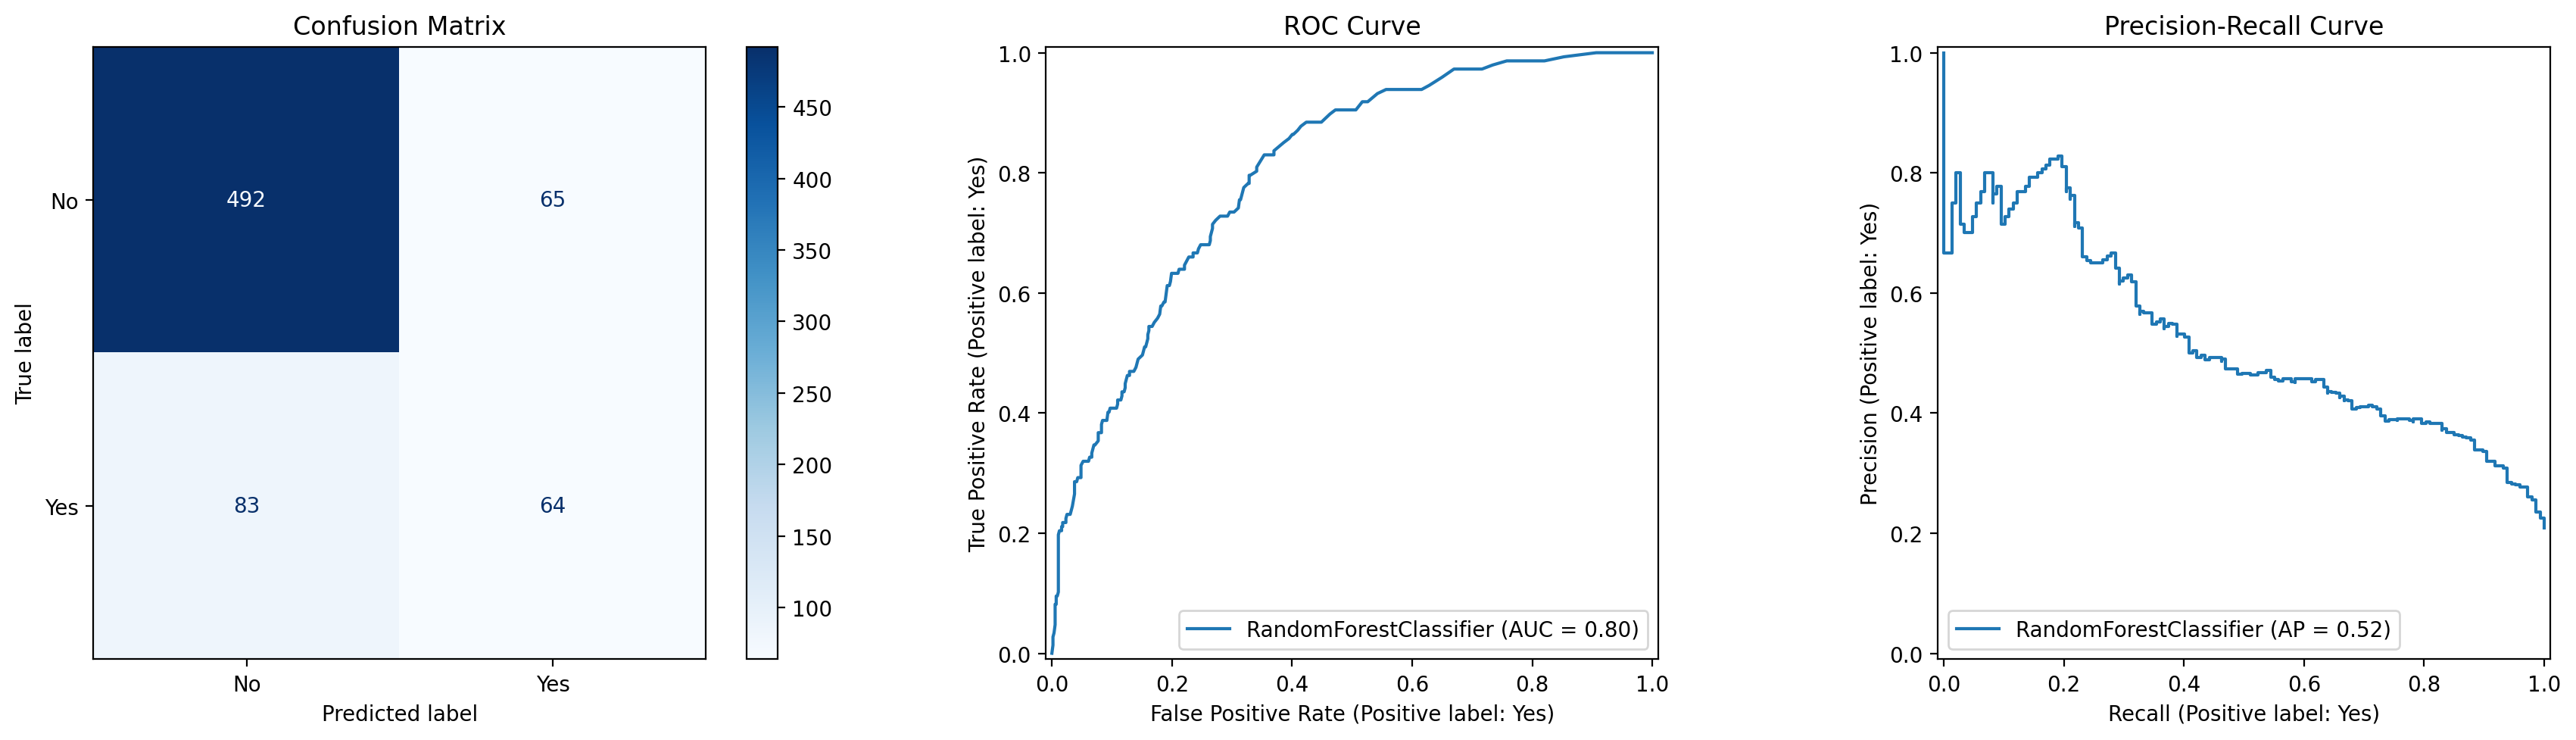

In [66]:
plot_metrics(forest_model, X_test, y_test)

In [67]:
print(classification_report(y_test, forest_pred))

              precision    recall  f1-score   support

          No       0.86      0.88      0.87       557
         Yes       0.50      0.44      0.46       147

    accuracy                           0.79       704
   macro avg       0.68      0.66      0.67       704
weighted avg       0.78      0.79      0.78       704



## 3.4 Adaptive Boosting

The final model which I will use is Adaptive Boosting. AdaBoost is an ensemble technique that builds a strong classifier by combining multiple weak learners, typically shallow decision trees. It works by training models sequentially, where each subsequent model focuses more on the instances that were previously misclassified. In doing so, it adaptively adjusts the weights of training instances, improving the overall predictive power. For this dataset, the AdaBoost model demonstrated the highest performance among the compared models with accuracy equal to 83%. It achieved the best classification metrics, indicating that the boosting technique effectively handled the patterns and imbalances present in the data.

In [68]:
ada_model = AdaBoostClassifier(n_estimators = 200)

In [69]:
ada_model.fit(X_train, y_train)

AdaBoostClassifier(n_estimators=200)

In [70]:
ada_pred = ada_model.predict(X_test)

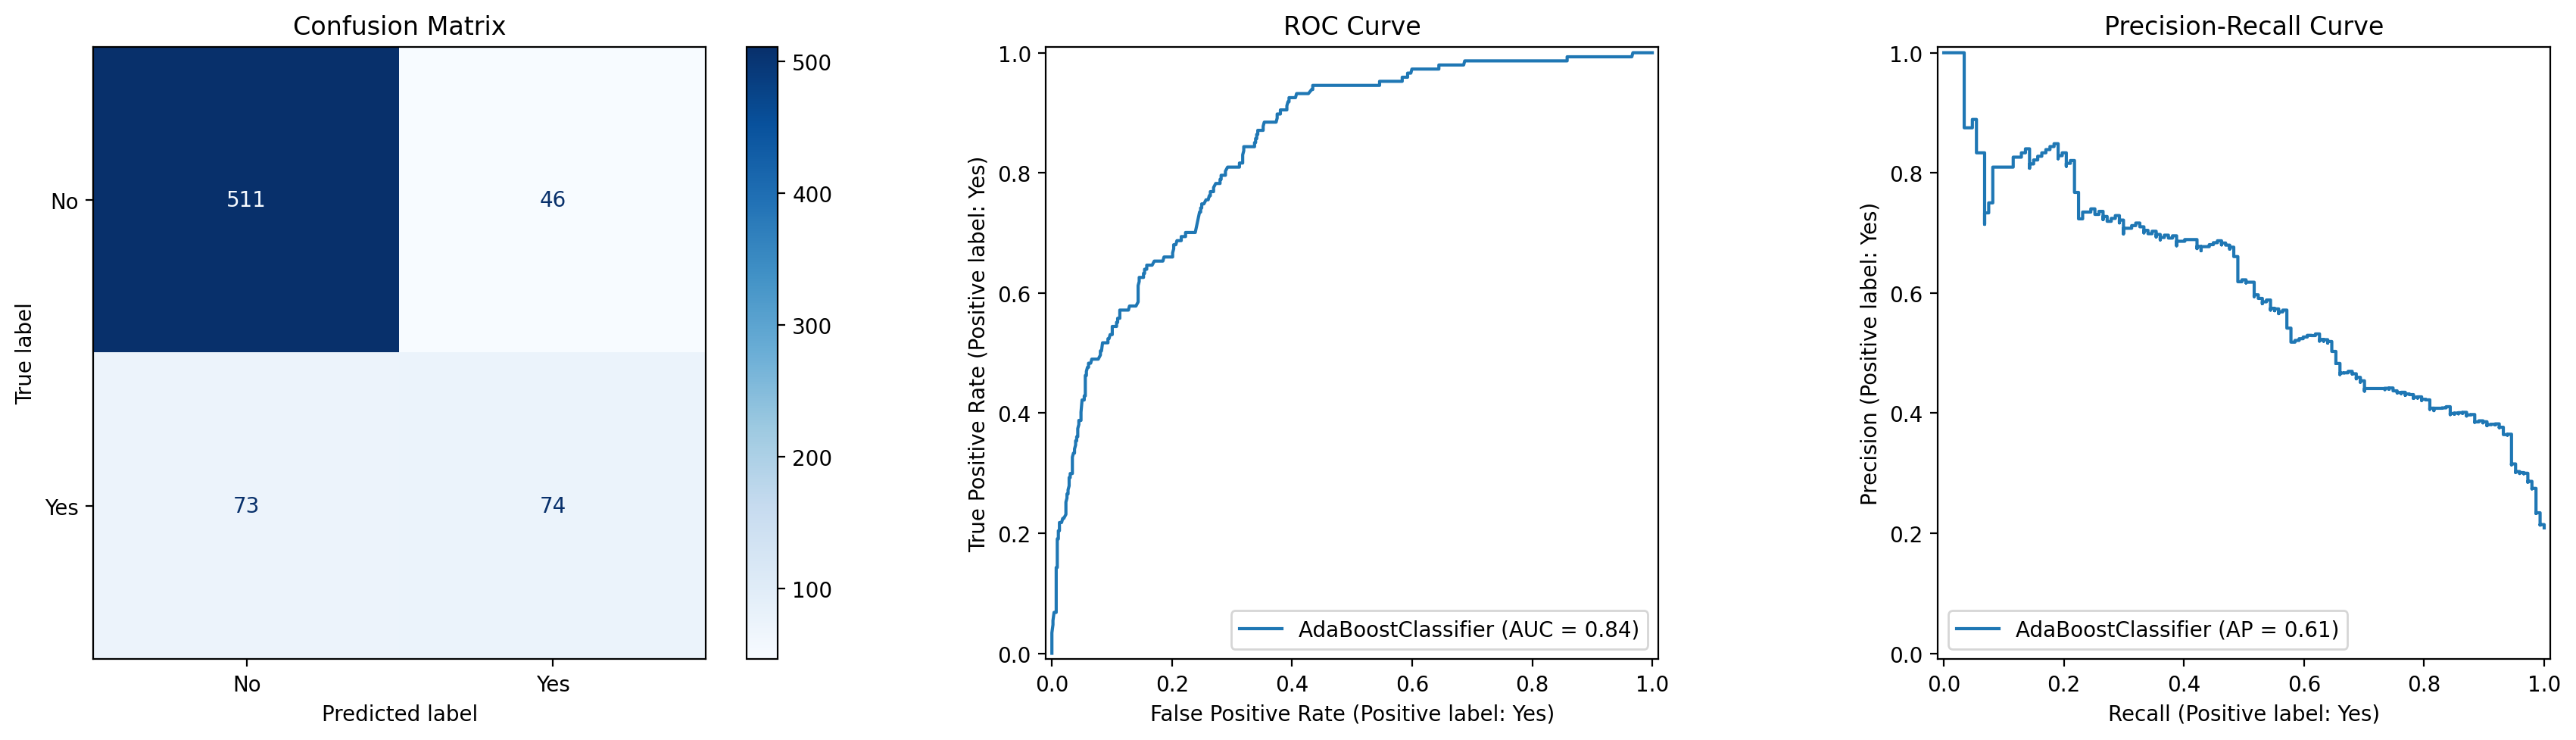

In [71]:
plot_metrics(ada_model, X_test, y_test)

In [72]:
print(classification_report(y_test, ada_pred))

              precision    recall  f1-score   support

          No       0.88      0.92      0.90       557
         Yes       0.62      0.50      0.55       147

    accuracy                           0.83       704
   macro avg       0.75      0.71      0.73       704
weighted avg       0.82      0.83      0.82       704



# 4. References

**[1]** https://www.kaggle.com/datasets/blastchar/telco-customer-churn